# Data C — Multires 2K λ=3: raw vs best-ambiguity pulse loss

Protocol follows Data C in `stochastic_multires_2k_noisy_trace_lambda_experiments.ipynb`:

| Item | Value |
|------|-------|
| Data | Data C (`t_center_std=9.5` fs, `canonicalize_mode=t0`) |
| Model | Multires (`TraceToPulseMultires`) |
| λ | **3** |
| Train size | 2048 |
| Val size | 200 |
| Train SNR | U[0, 30] dB |
| **Val SNR** | **U[−10, 30] dB** (noisy each epoch) |
| Trace scale | median ratio calibration (same as Data C λ search) |

## Two models
1. **A (`raw`)** — train pulse L1 on raw \(\hat E\) vs \(E\).
2. **B (`best_ambiguity`)** — train pulse L1 on best-ambiguity–aligned \(\hat E\) vs \(E\).

Both log every epoch: pulse L1 raw/amb (train+val), trace L1 (train+val),
\(\|\nabla L_{\mathrm{data}}\|\), \(\|\nabla L_{\mathrm{reg}}\|\), and timing breakdown.

Helpers: `data_c_amb_loss_diagnostics.py`  
Artifacts: `checkpoints/benchmark/data_c_amb_loss_diagnostics/`

**Model selection note:** early-stop / best checkpoint should use **val pulse L1 after best ambiguity** for *both* models (fixed in `data_c_amb_loss_diagnostics.py` for future runs; existing checkpoints were trained with the previous rule).

**Held-out test:** SNR sweep on Data C test split (`seed+2`, not used for early stop).

Also: **Model B_fast** uses the accelerated best-ambiguity backend (GPU + FFT); legacy B is kept.


In [19]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

SRC = Path.cwd()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import importlib
import pulse_metrics
importlib.reload(pulse_metrics)
import data_c_amb_loss_diagnostics as diag
importlib.reload(diag)

OUT = SRC / "checkpoints" / "benchmark" / "data_c_amb_loss_diagnostics"
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("OUT:", OUT)

# --- toggles ---
# Model A loss = raw pulse L1; Model B loss = best-ambiguity pulse L1.
# Early-stop / best ckpt for BOTH: val pulse L1 after best ambiguity.
RUN_TRAIN_A = True
RUN_TRAIN_B = False          # keep existing B checkpoint
FORCE_TRAIN_A = False         # retrain A with updated early-stop (amb)
FORCE_TRAIN_B = False
RUN_TEST_SWEEP = True
FORCE_TEST_SWEEP_A = False    # refresh A's held-out SNR sweep after retrain
FORCE_TEST_SWEEP_B = False

# Model B with fast best-ambiguity (GPU + FFT) — separate artifacts
RUN_TRAIN_B_FAST = True
FORCE_TRAIN_B_FAST = False
FORCE_TEST_SWEEP_B_FAST = False

LAM = 3.0
N_TRAIN = 2048
N_VAL = 200
N_TEST = 512
MAX_EPOCHS = 200
PATIENCE = 25
SEED = 0
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)


device: cuda
OUT: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics


## Train Model A — pulse L1 **without** best ambiguity in the loss

Logged curves still include both raw and best-ambiguity pulse L1 on train/val.


In [20]:
tag_a = "model_a_raw_pulse_loss"
path_a = OUT / f"{tag_a}_history.npz"

if RUN_TRAIN_A and (FORCE_TRAIN_A or not path_a.exists()):
    print("Training Model A (raw pulse L1)...")
    res_a = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="raw",
        lam=LAM,
        n_train=N_TRAIN,
        n_val=N_VAL,
        seed=SEED,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=DEVICE,
        verbose=True,
    )
    diag.save_run_artifacts(res_a, OUT, tag_a)
    print("saved", tag_a)
else:
    print("skip Model A train; using", path_a if path_a.exists() else "(missing)")

hist_a = diag.load_history(path_a) if path_a.exists() else None
meta_a = json.loads((OUT / f"{tag_a}_meta.json").read_text(encoding="utf-8")) if (OUT / f"{tag_a}_meta.json").exists() else None
if meta_a:
    print(json.dumps(meta_a, indent=2))


skip Model A train; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_pulse_loss_history.npz
{
  "best_epoch": 79,
  "best_score": 2.3637456995248796,
  "stopped_epoch": 104,
  "lam": 3.0,
  "trace_scale": 7.877140336074978,
  "pulse_loss_mode": "raw",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "n_train": 2048,
  "n_val": 200,
  "seed": 0
}


## Train Model B — pulse L1 **with** best ambiguity in the loss

Training loss uses \(\| E - \mathrm{BestAmb}(\hat E)\|_1\) (aligned reconstruction).
Trace / physics term still uses the raw network output \(\hat E\) (FROG of \(\hat E\)).


In [21]:
tag_b = "model_b_amb_pulse_loss"
path_b = OUT / f"{tag_b}_history.npz"

if RUN_TRAIN_B and (FORCE_TRAIN_B or not path_b.exists()):
    print("Training Model B (best-ambiguity pulse L1)...")
    res_b = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="best_ambiguity",
        lam=LAM,
        n_train=N_TRAIN,
        n_val=N_VAL,
        seed=SEED,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=DEVICE,
        verbose=True,
    )
    diag.save_run_artifacts(res_b, OUT, tag_b)
    print("saved", tag_b)
else:
    print("skip Model B train; using", path_b if path_b.exists() else "(missing)")

hist_b = diag.load_history(path_b) if path_b.exists() else None
meta_b = json.loads((OUT / f"{tag_b}_meta.json").read_text(encoding="utf-8")) if (OUT / f"{tag_b}_meta.json").exists() else None
if meta_b:
    print(json.dumps(meta_b, indent=2))


skip Model B train; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_b_amb_pulse_loss_history.npz
{
  "best_epoch": 78,
  "best_score": 2.21168182849884,
  "stopped_epoch": 103,
  "lam": 3.0,
  "trace_scale": 7.7575333480202735,
  "pulse_loss_mode": "best_ambiguity",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "n_train": 2048,
  "n_val": 200,
  "seed": 0
}


## Plot helpers


In [42]:
def _epochs(y):
    return np.arange(1, len(y) + 1)


def plot_pulse_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = _epochs(hist["train_pulse_l1_raw"])
    axes[0].plot(ep, hist["train_pulse_l1_raw"], label="raw")
    axes[0].plot(ep, hist["train_pulse_l1_amb"], label="best amb")
    axes[0].set_title(f"{title_prefix}: train pulse L1")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("pulse L1")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, hist["val_pulse_l1_raw"], label="raw")
    axes[1].plot(ep, hist["val_pulse_l1_amb"], label="best amb")
    axes[1].set_title(f"{title_prefix}: val pulse L1 (SNR~U[-10,30])")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("pulse L1")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_trace_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = _epochs(hist["train_trace_l1"])
    axes[0].plot(ep, hist["train_trace_l1"], color="C2")
    axes[0].set_title(f"{title_prefix}: train trace L1")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("trace L1")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, hist["val_trace_l1"], color="C3")
    axes[1].set_title(f"{title_prefix}: val trace L1 (SNR~U[-10,30])")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("trace L1")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_grad_norms(hist, title_prefix):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = _epochs(hist["grad_norm_data"])
    ax.plot(ep, hist["grad_norm_data"], label=r"$\|\nabla L_{data}\|$")
    ax.plot(ep, hist["grad_norm_reg"], label=r"$\|\nabla L_{reg}\|$")
    ax.set_title(f"{title_prefix}: gradient norms (end of epoch probe)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("L2 grad norm")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_grad_norms_linear_separate(hist, title_prefix):
    """Pulse (L_data) and TRACE (L_reg) gradient norms on separate linear-scale panels."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = _epochs(hist["grad_norm_data"])
    axes[0].plot(ep, hist["grad_norm_data"], color="C0")
    axes[0].set_title(rf"{title_prefix}: $\|\nabla L_{{\mathrm{{pulse}}}}\|$ (linear)")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel(r"$\|\nabla L_{\mathrm{pulse}}\|$")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, hist["grad_norm_reg"], color="C1")
    axes[1].set_title(rf"{title_prefix}: $\|\nabla L_{{\mathrm{{trace}}}}\|$ (linear)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel(r"$\|\nabla L_{\mathrm{trace}}\|$")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_timings(hist, title_prefix, *, y_percentile=99.0):
    """Plot timing curves with y-limits from robust percentiles (ignore spikes)."""
    keys = [
        ("timing_data_prep_sec", "Data Prep"),
        ("timing_loss_data_fwd_sec", "Loss Data Fwd"),
        ("timing_loss_reg_fwd_sec", "Loss Reg Fwd"),
        ("timing_total_backward_sec", "Total Backward"),
        ("timing_optimizer_step_sec", "Optimizer Step"),
    ]
    series_ms = {lab: np.asarray(hist[k], dtype=float) * 1e3 for k, lab in keys}
    all_ms = np.concatenate(list(series_ms.values()))
    y_hi = float(np.percentile(all_ms, y_percentile))
    # small headroom; avoid zero-span
    y_hi = max(y_hi * 1.15, float(np.median(all_ms)) * 1.5, 1.0)

    fig, ax = plt.subplots(figsize=(10, 4))
    ep = _epochs(hist[keys[0][0]])
    for lab, y in series_ms.items():
        ax.plot(ep, y, label=lab)
        # mark clipped outliers (points above display limit)
        mask = y > y_hi
        if np.any(mask):
            ax.scatter(ep[mask], np.full(mask.sum(), y_hi), marker="^", s=40, zorder=5)
            for e_out, v_out in zip(ep[mask], y[mask]):
                ax.annotate(
                    f"{lab}: {v_out:.0f} ms @ ep {int(e_out)}",
                    xy=(e_out, y_hi),
                    xytext=(5, 8),
                    textcoords="offset points",
                    fontsize=7,
                    rotation=0,
                )

    ax.set_ylim(0.0, y_hi)
    ax.set_title(
        f"{title_prefix}: mean per-batch times (ms)\n"
        f"(y-axis ≤ {y_percentile:.0f}th pct; outliers marked ▲)"
    )
    ax.set_xlabel("epoch")
    ax.set_ylabel("ms / batch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def summarize_timings(hist, name):
    print(f"=== {name}: mean±std over epochs (ms/batch) ===")
    for k, lab in [
        ("timing_data_prep_sec", "Data Prep"),
        ("timing_loss_data_fwd_sec", "Loss Data Fwd"),
        ("timing_loss_reg_fwd_sec", "Loss Reg Fwd"),
        ("timing_total_backward_sec", "Total Backward"),
        ("timing_optimizer_step_sec", "Optimizer Step"),
    ]:
        x = np.asarray(hist[k]) * 1e3
        print(f"  {lab:18s}: {x.mean():8.3f} ± {x.std():7.3f}")


def plot_pulse_trace_trajectories(hist, title_prefix):
    """
    Epoch trajectories in (pulse L1, trace L1) space.

    Panels:
      1) validation — X = pulse L1 best-amb, Y = trace L1
      2) train — X = pulse L1 best-amb, Y = trace L1
      3) train — X = pulse L1 raw (no amb), Y = trace L1
    """
    panels = [
        (
            "val_pulse_l1_amb",
            "val_trace_l1",
            "Val: pulse L1 best-amb vs trace L1",
            "pulse L1 (best amb)",
        ),
        (
            "train_pulse_l1_amb",
            "train_trace_l1",
            "Train: pulse L1 best-amb vs trace L1",
            "pulse L1 (best amb)",
        ),
        (
            "train_pulse_l1_raw",
            "train_trace_l1",
            "Train: pulse L1 raw vs trace L1",
            "pulse L1 (raw)",
        ),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (xk, yk, title, xlab) in zip(axes, panels):
        x = np.asarray(hist[xk], dtype=float)
        y = np.asarray(hist[yk], dtype=float)
        ep = _epochs(x)
        ax.plot(x, y, "-", color="0.55", lw=1.2, zorder=1)
        sc = ax.scatter(
            x,
            y,
            c=ep,
            cmap="viridis",
            s=22,
            zorder=2,
            edgecolors="none",
        )
        ax.scatter(
            [x[0]],
            [y[0]],
            s=80,
            marker="o",
            facecolors="none",
            edgecolors="C3",
            linewidths=2,
            zorder=3,
            label=f"start ep {int(ep[0])}",
        )
        ax.scatter(
            [x[-1]],
            [y[-1]],
            s=90,
            marker="*",
            c="C1",
            zorder=3,
            label=f"end ep {int(ep[-1])}",
        )
        ax.set_title(title)
        ax.set_xlabel(xlab)
        ax.set_ylabel("trace L1")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="epoch")
    fig.suptitle(f"{title_prefix}: pulse–trace error trajectories", fontweight="bold")
    plt.tight_layout()
    plt.show()


## Model A plots (raw pulse loss)

Includes pulse–trace **error trajectories** (X = pulse L1, Y = trace L1; one point per epoch, connected):
validation best-amb, train best-amb, and train raw (no amb).


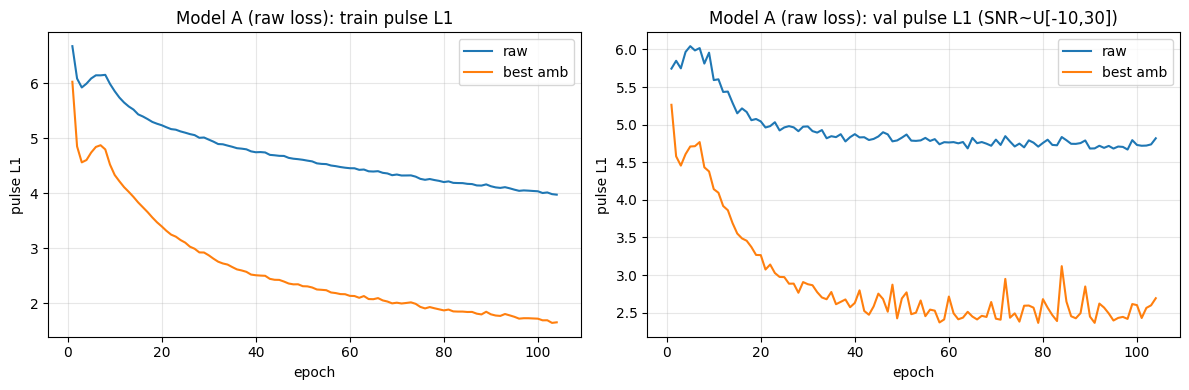

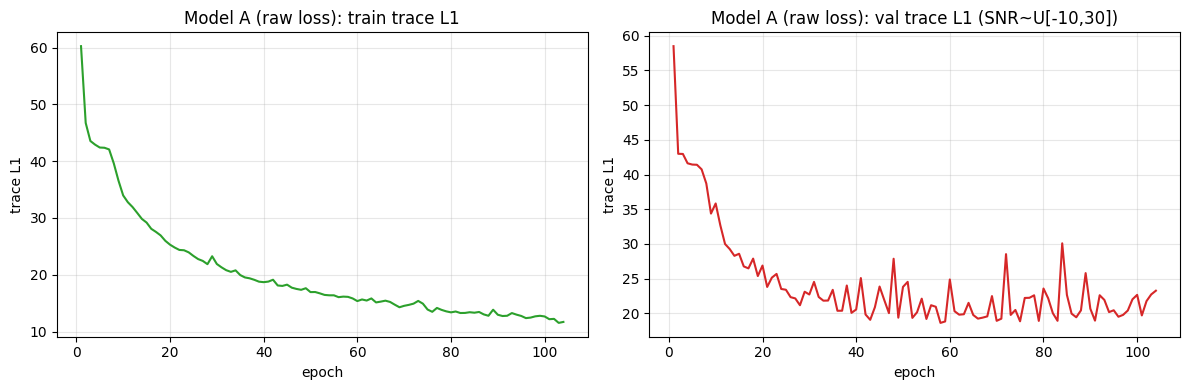

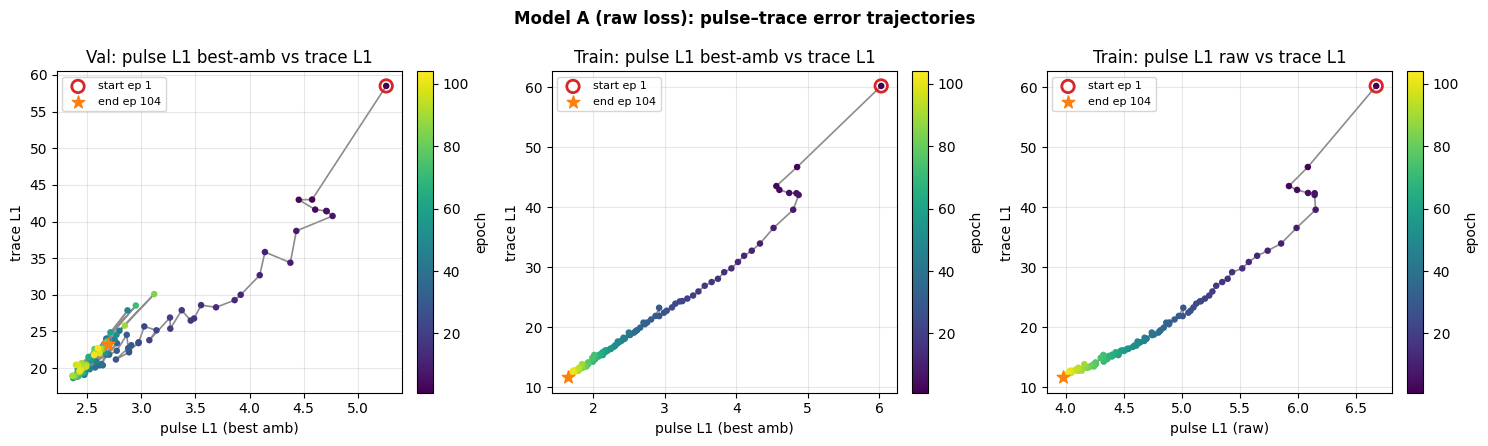

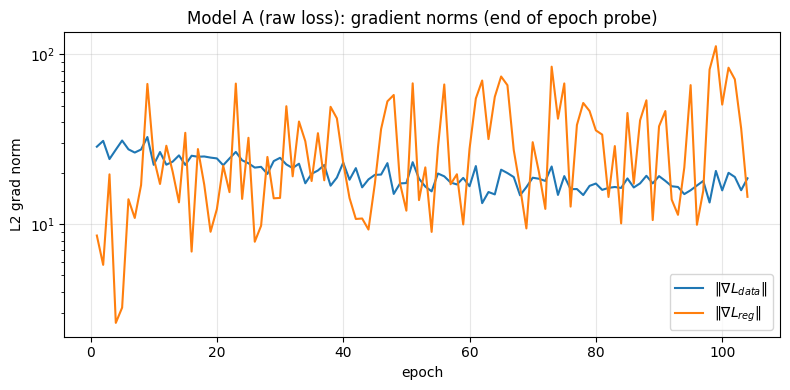

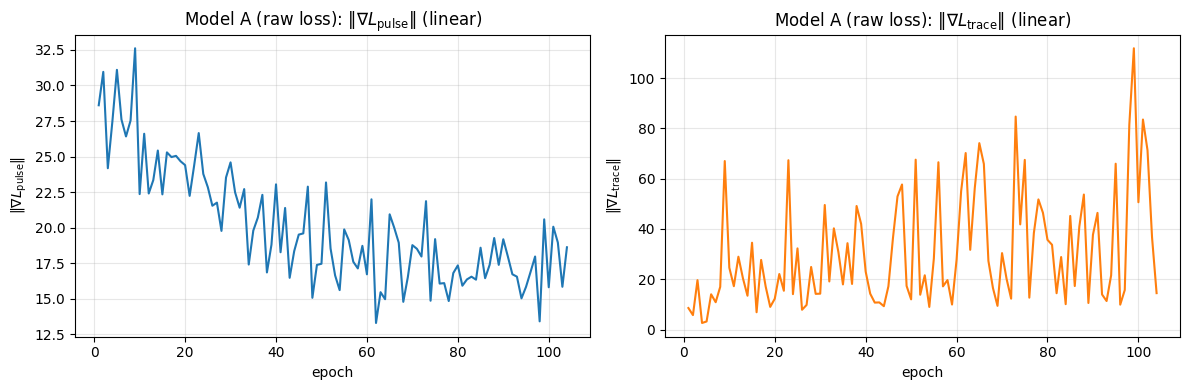

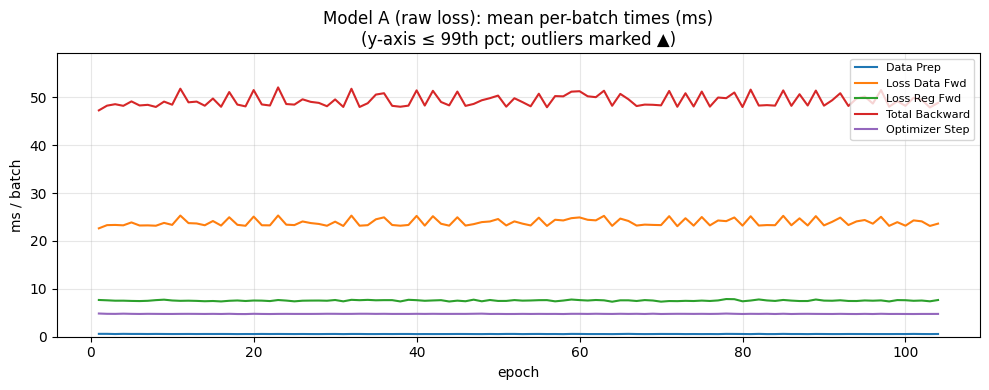

=== Model A: mean±std over epochs (ms/batch) ===
  Data Prep         :    0.566 ±   0.013
  Loss Data Fwd     :   23.891 ±   0.739
  Loss Reg Fwd      :    7.552 ±   0.112
  Total Backward    :   49.325 ±   1.260
  Optimizer Step    :    4.771 ±   0.019


In [44]:
assert hist_a is not None, "Model A history missing — set RUN_TRAIN_A=True and re-run"
plot_pulse_curves(hist_a, "Model A (raw loss)")
plot_trace_curves(hist_a, "Model A (raw loss)")
plot_pulse_trace_trajectories(hist_a, "Model A (raw loss)")
plot_grad_norms(hist_a, "Model A (raw loss)")
plot_grad_norms_linear_separate(hist_a, "Model A (raw loss)")
plot_timings(hist_a, "Model A (raw loss)")
summarize_timings(hist_a, "Model A")


## Model B plots (best-ambiguity pulse loss)


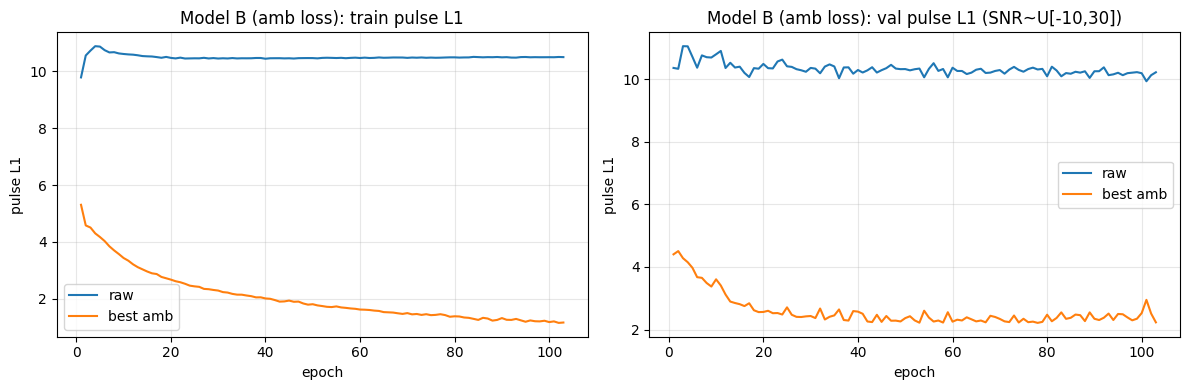

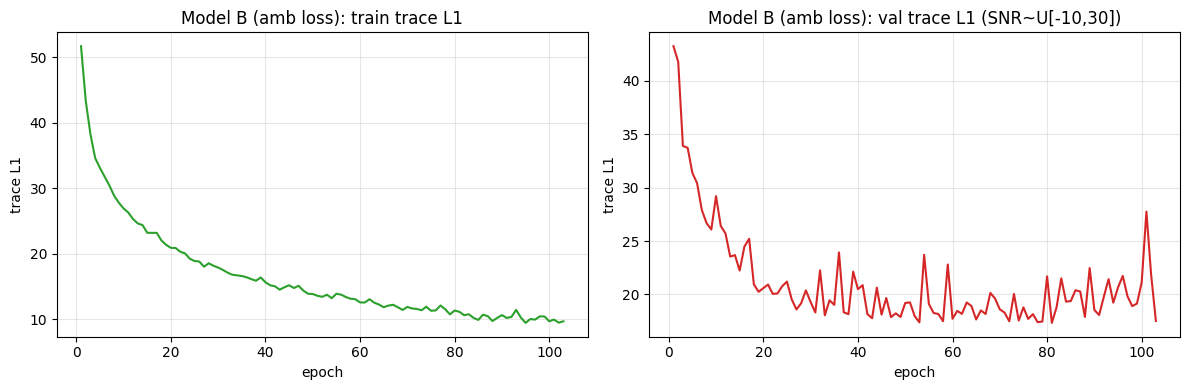

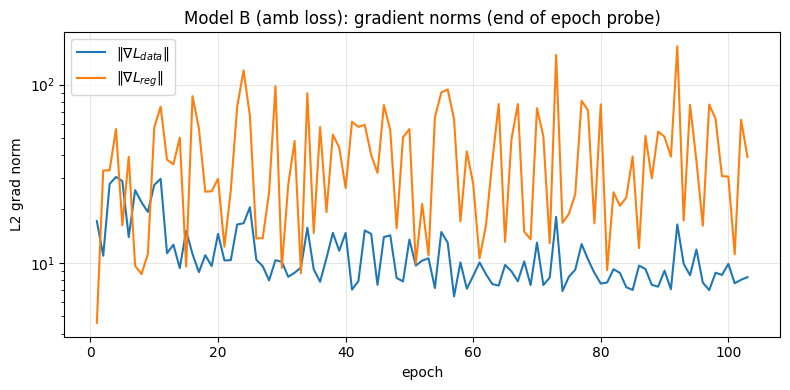

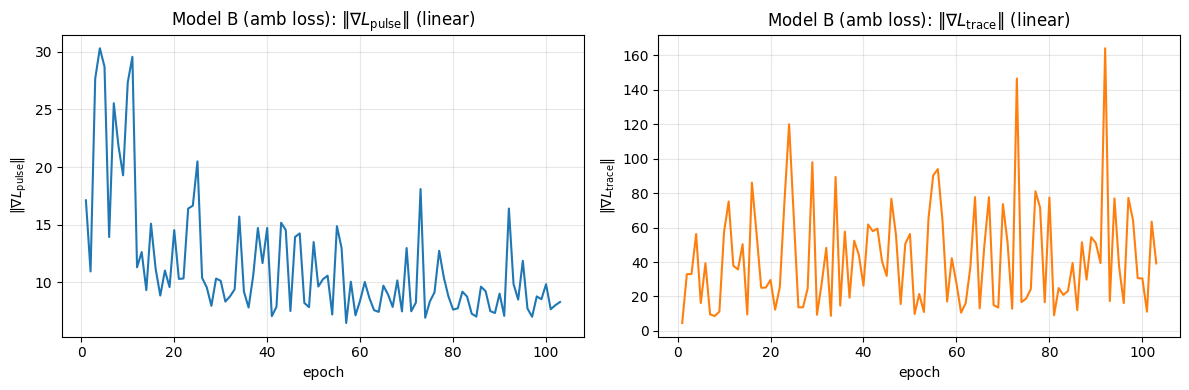

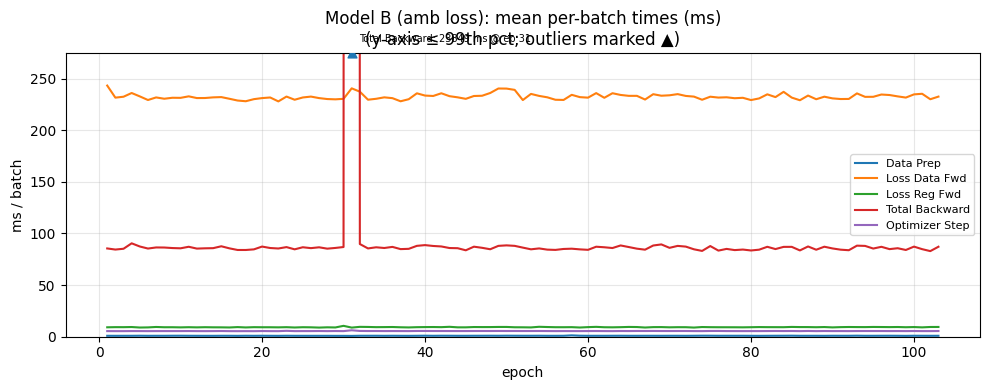

=== Model B: mean±std over epochs (ms/batch) ===
  Data Prep         :    0.918 ±   0.056
  Loss Data Fwd     :  232.439 ±   2.789
  Loss Reg Fwd      :    9.245 ±   0.212
  Total Backward    :  316.661 ± 2330.070
  Optimizer Step    :    5.492 ±   0.090


In [45]:
assert hist_b is not None, "Model B history missing — set RUN_TRAIN_B=True and re-run"
plot_pulse_curves(hist_b, "Model B (amb loss)")
plot_trace_curves(hist_b, "Model B (amb loss)")
plot_grad_norms(hist_b, "Model B (amb loss)")
plot_grad_norms_linear_separate(hist_b, "Model B (amb loss)")
plot_timings(hist_b, "Model B (amb loss)")
summarize_timings(hist_b, "Model B")


## Side-by-side comparison


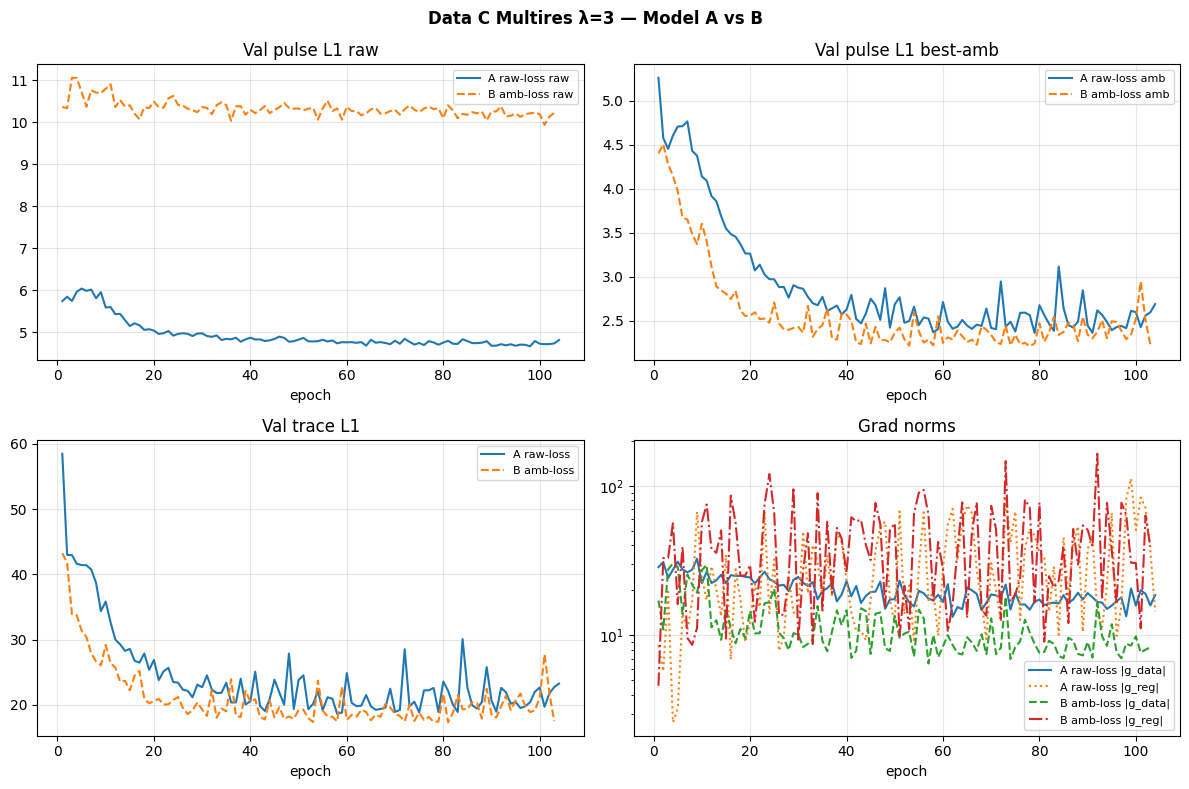

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for hist, name, ls in [(hist_a, "A raw-loss", "-"), (hist_b, "B amb-loss", "--")]:
    ep = _epochs(hist["val_pulse_l1_raw"])
    axes[0, 0].plot(ep, hist["val_pulse_l1_raw"], ls=ls, label=f"{name} raw")
    axes[0, 1].plot(ep, hist["val_pulse_l1_amb"], ls=ls, label=f"{name} amb")
    axes[1, 0].plot(ep, hist["val_trace_l1"], ls=ls, label=name)
    axes[1, 1].plot(ep, hist["grad_norm_data"], ls=ls, label=f"{name} |g_data|")
    axes[1, 1].plot(ep, hist["grad_norm_reg"], ls=":" if ls == "-" else "-.", label=f"{name} |g_reg|")

axes[0, 0].set_title("Val pulse L1 raw")
axes[0, 1].set_title("Val pulse L1 best-amb")
axes[1, 0].set_title("Val trace L1")
axes[1, 1].set_title("Grad norms")
axes[1, 1].set_yscale("log")
for ax in axes.ravel():
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle("Data C Multires λ=3 — Model A vs B", fontweight="bold")
plt.tight_layout()
plt.show()


## Held-out test SNR sweep

Evaluate both saved Multires checkpoints on the **Data C test split**
(`n_test=512`, generation `seed+2`) — **not** the validation set used for early stop.

SNR grid: \([-10, 30]\) dB step 5 (same as Data C λ experiments).
Reports pulse L1 / similarity, raw and best-ambiguity.


In [26]:

from evaluate_cnn import load_cnn_sweep, plot_metric_curves

tag_a = "model_a_raw_pulse_loss"
tag_b = "model_b_amb_pulse_loss"
sweep_path_a = OUT / f"{tag_a}_test_snr_sweep.npz"
sweep_path_b = OUT / f"{tag_b}_test_snr_sweep.npz"

test_loader = diag.build_data_c_test_loader(
    n_train=N_TRAIN,
    n_val=N_VAL,
    n_test=N_TEST,
    seed=SEED,
    device=DEVICE,
)
print("test batches:", len(test_loader), "| SNR grid:", SNR_SWEEP_DB.tolist())

if RUN_TEST_SWEEP and (FORCE_TEST_SWEEP_A or not sweep_path_a.exists()):
    print("Running test SNR sweep — Model A...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{tag_a}_model.pt",
        sweep_path_a,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name="data_c_model_a_raw_pulse_loss",
        verbose=True,
    )
else:
    print("skip Model A sweep; using", sweep_path_a if sweep_path_a.exists() else "(missing)")

if RUN_TEST_SWEEP and (FORCE_TEST_SWEEP_B or not sweep_path_b.exists()):
    print("Running test SNR sweep — Model B...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{tag_b}_model.pt",
        sweep_path_b,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name="data_c_model_b_amb_pulse_loss",
        verbose=True,
    )
else:
    print("skip Model B sweep; using", sweep_path_b if sweep_path_b.exists() else "(missing)")

sweep_a = load_cnn_sweep(sweep_path_a)
sweep_b = load_cnn_sweep(sweep_path_b)
print("loaded sweeps:", sweep_path_a.name, sweep_path_b.name)


test batches: 8 | SNR grid: [-10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
skip Model A sweep; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_pulse_loss_test_snr_sweep.npz
skip Model B sweep; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_b_amb_pulse_loss_test_snr_sweep.npz
loaded sweeps: model_a_raw_pulse_loss_test_snr_sweep.npz model_b_amb_pulse_loss_test_snr_sweep.npz


### Test metrics vs SNR — **best ambiguity only**

Pulse L1 and similarity error after applying best ambiguity to the reconstructed pulse (raw metrics omitted).


Held-out test L1 best-amb (mean): B is lower/better at every SNR
   SNR        A        B      A-B
   -10   3.3990   3.1513   0.2476
    -5   2.7537   2.6173   0.1364
     0   2.5618   2.4633   0.0985
     5   2.4872   2.3634   0.1238
    10   2.4499   2.3327   0.1172
    15   2.4454   2.3231   0.1223
    20   2.4406   2.3214   0.1192
    25   2.4402   2.3205   0.1197
    30   2.4413   2.3222   0.1191


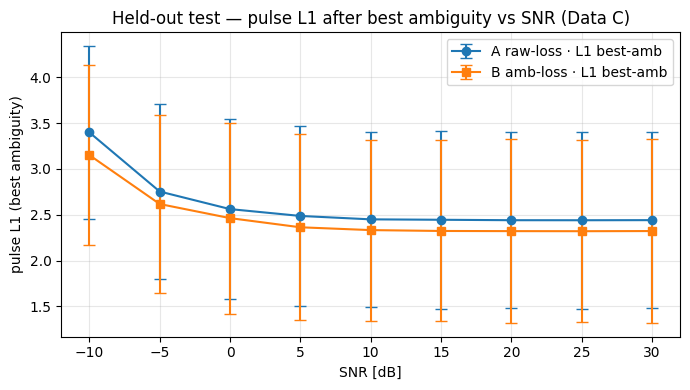

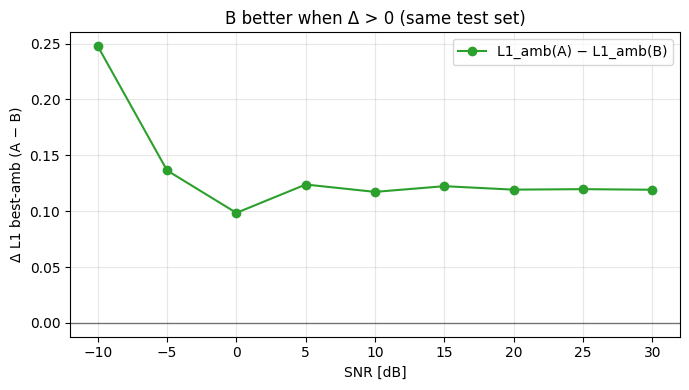

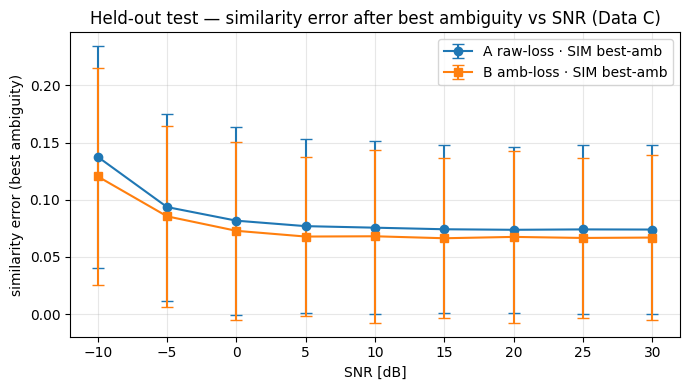

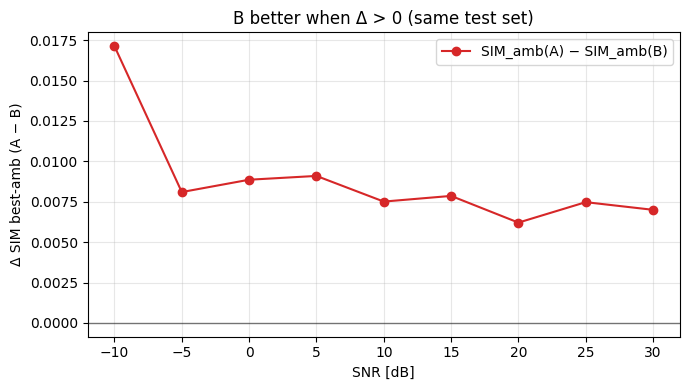

In [27]:

snr = sweep_a.snr_sweep_db
delta_l1 = np.asarray(sweep_a.cnn_l1_amb_m) - np.asarray(sweep_b.cnn_l1_amb_m)
delta_sim = np.asarray(sweep_a.cnn_sim_amb_m) - np.asarray(sweep_b.cnn_sim_amb_m)

print("Held-out test L1 best-amb (mean): B is lower/better at every SNR")
print(f"{'SNR':>6s} {'A':>8s} {'B':>8s} {'A-B':>8s}")
for i, s in enumerate(snr):
    print(
        f"{float(s):6.0f} {float(sweep_a.cnn_l1_amb_m[i]):8.4f} "
        f"{float(sweep_b.cnn_l1_amb_m[i]):8.4f} {float(delta_l1[i]):8.4f}"
    )

plot_metric_curves(
    snr,
    [
        (sweep_a.cnn_l1_amb_m, sweep_a.cnn_l1_amb_s, "o-", "A raw-loss · L1 best-amb"),
        (sweep_b.cnn_l1_amb_m, sweep_b.cnn_l1_amb_s, "s-", "B amb-loss · L1 best-amb"),
    ],
    xlabel="SNR [dB]",
    ylabel="pulse L1 (best ambiguity)",
    title="Held-out test — pulse L1 after best ambiguity vs SNR (Data C)",
)

# Difference plot: positive => B better
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snr, delta_l1, "o-", color="C2", label="L1_amb(A) − L1_amb(B)")
ax.axhline(0.0, color="k", lw=1, alpha=0.5)
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Δ L1 best-amb (A − B)")
ax.set_title("B better when Δ > 0 (same test set)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

plot_metric_curves(
    snr,
    [
        (sweep_a.cnn_sim_amb_m, sweep_a.cnn_sim_amb_s, "o-", "A raw-loss · SIM best-amb"),
        (sweep_b.cnn_sim_amb_m, sweep_b.cnn_sim_amb_s, "s-", "B amb-loss · SIM best-amb"),
    ],
    xlabel="SNR [dB]",
    ylabel="similarity error (best ambiguity)",
    title="Held-out test — similarity error after best ambiguity vs SNR (Data C)",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snr, delta_sim, "o-", color="C3", label="SIM_amb(A) − SIM_amb(B)")
ax.axhline(0.0, color="k", lw=1, alpha=0.5)
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Δ SIM best-amb (A − B)")
ax.set_title("B better when Δ > 0 (same test set)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### Compact comparison table (test)


In [28]:
rows = []
for tag, sw in [("A raw-loss", sweep_a), ("B amb-loss", sweep_b)]:
    for i, snr_db in enumerate(sw.snr_sweep_db):
        rows.append(
            (
                tag,
                float(snr_db),
                float(sw.cnn_l1_amb_m[i]),
                float(sw.cnn_sim_amb_m[i]),
            )
        )

print(f"{'model':12s} {'SNR':>6s} {'L1_amb':>8s} {'SIM_amb':>8s}")
for model, snr_db, l1a, sa in rows:
    if snr_db in (-10.0, 0.0, 15.0, 30.0):
        print(f"{model:12s} {snr_db:6.0f} {l1a:8.4f} {sa:8.4f}")


model           SNR   L1_amb  SIM_amb
A raw-loss      -10   3.3990   0.1375
A raw-loss        0   2.5618   0.0817
A raw-loss       15   2.4454   0.0742
A raw-loss       30   2.4413   0.0739
B amb-loss      -10   3.1513   0.1203
B amb-loss        0   2.4633   0.0728
B amb-loss       15   2.3231   0.0663
B amb-loss       30   2.3222   0.0669


## Example: clean vs noisy TRACE @ 10 dB + reconstructions (A vs B)

Each run of the next cell draws a **new random** held-out test sample (same test pool as the SNR sweep),
shows clean vs noisy SHG-FROG (SNR = 10 dB), and overlays time-domain $|E(t)|$ / phase for Models A and B
(reconstructions after **best ambiguity** alignment to GT).


Drew test sample index 281 / 511
Example sample 281 @ SNR=10 dB — pulse L1:
  Model A: raw=4.3621  best-amb=1.8579
  Model B: raw=12.2069  best-amb=2.1252


C:\Users\SharonLab\AppData\Local\Temp\ipykernel_30388\42811231.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


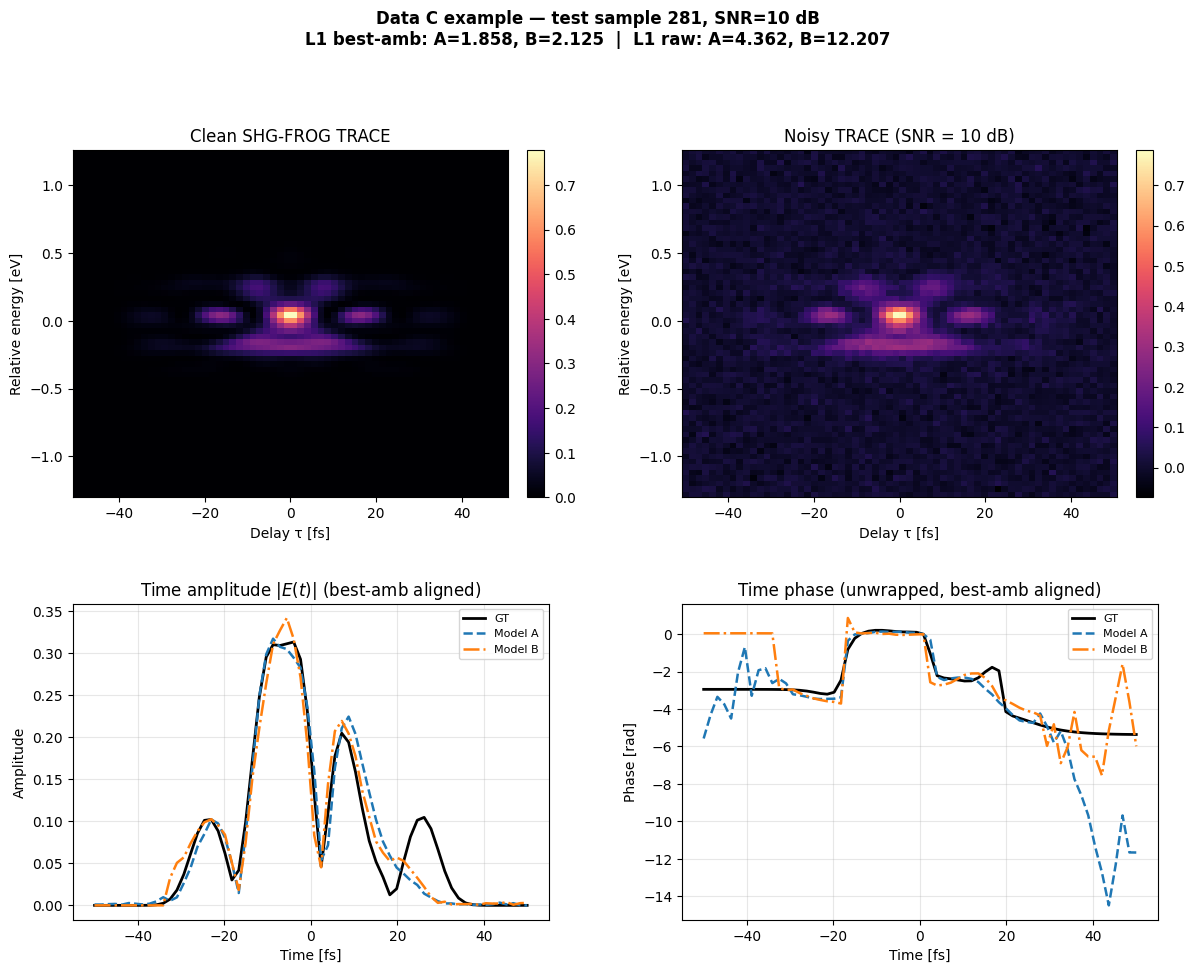

In [29]:

from data_generation import phase_t_unwrapped_at_zero, stochastic_pulse_config_data_c
from frog_reconstruction_model import extract_pulse_prediction
from pulse_metrics import (
    best_l1_ambiguity_field,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn

EXAMPLE_SNR_DB = 10.0

cfg = stochastic_pulse_config_data_c(n=64)
t_axis = np.linspace(-cfg.t_total_fs / 2.0, cfg.t_total_fs / 2.0, cfg.n)
dt = cfg.t_total_fs / max(cfg.n - 1, 1)

# Reuse test_loader if already built; otherwise build it
if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

# New random held-out test sample on every run of this cell
_test_ds = test_loader.dataset
n_test_available = len(_test_ds)
EXAMPLE_INDEX = int(np.random.randint(0, n_test_available))
I_clean, E_true_packed = _test_ds[EXAMPLE_INDEX]
I_clean = I_clean.to(DEVICE)
E_true_packed = E_true_packed.to(DEVICE)
I_noisy = add_trace_noise_awgn(I_clean.unsqueeze(0), EXAMPLE_SNR_DB).squeeze(0)
print(f"Drew test sample index {EXAMPLE_INDEX} / {n_test_available - 1}")

tag_a = globals().get("tag_a", "model_a_raw_pulse_loss")
tag_b = globals().get("tag_b", "model_b_amb_pulse_loss")
model_a = diag.load_trained_multires(OUT / f"{tag_a}_model.pt", device=DEVICE)
model_b = diag.load_trained_multires(OUT / f"{tag_b}_model.pt", device=DEVICE)

with torch.no_grad():
    x = I_noisy.unsqueeze(0).unsqueeze(0)  # [1,1,N,N]
    E_a = extract_pulse_prediction(model_a(x)).squeeze(0).cpu().numpy()
    E_b = extract_pulse_prediction(model_b(x)).squeeze(0).cpu().numpy()

e_true = unpack_packed_field(E_true_packed.detach().cpu().numpy())
e_a = unpack_packed_field(E_a)
e_b = unpack_packed_field(E_b)
e_a_al = best_l1_ambiguity_field(e_a, e_true)
e_b_al = best_l1_ambiguity_field(e_b, e_true)

from pulse_metrics import best_l1_ambiguity, pack_complex_field

def _l1_packed(e_rec, e_ref):
    return float(np.abs(pack_complex_field(e_rec) - pack_complex_field(e_ref)).sum())

l1_a_raw = _l1_packed(e_a, e_true)
l1_b_raw = _l1_packed(e_b, e_true)
l1_a_amb = best_l1_ambiguity(e_a, e_true)
l1_b_amb = best_l1_ambiguity(e_b, e_true)
print(
    f"Example sample {EXAMPLE_INDEX} @ SNR={EXAMPLE_SNR_DB:.0f} dB — pulse L1:\n"
    f"  Model A: raw={l1_a_raw:.4f}  best-amb={l1_a_amb:.4f}\n"
    f"  Model B: raw={l1_b_raw:.4f}  best-amb={l1_b_amb:.4f}"
)

phase_true = phase_t_unwrapped_at_zero(e_true)
_, phase_a = unwrap_phases_for_overlay(e_a_al, e_true)
_, phase_b = unwrap_phases_for_overlay(e_b_al, e_true)

trace_clean, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_clean.detach().cpu().numpy(), num_points=cfg.n, dt=dt
)
trace_noisy, _, _ = prepare_frog_trace_for_plot(
    I_noisy.detach().cpu().numpy(), num_points=cfg.n, dt=dt
)
h_ev_fs = 4.135667696
energy_plot = omega_plot * h_ev_fs / (2.0 * np.pi)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0], hspace=0.32, wspace=0.28)

ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(
    trace_clean,
    origin="lower",
    aspect="auto",
    extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
    cmap="magma",
)
ax0.set_title("Clean SHG-FROG TRACE")
ax0.set_xlabel("Delay τ [fs]")
ax0.set_ylabel("Relative energy [eV]")
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(
    trace_noisy,
    origin="lower",
    aspect="auto",
    extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
    cmap="magma",
)
ax1.set_title(f"Noisy TRACE (SNR = {EXAMPLE_SNR_DB:.0f} dB)")
ax1.set_xlabel("Delay τ [fs]")
ax1.set_ylabel("Relative energy [eV]")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t_axis, np.abs(e_true), "k-", lw=2, label="GT")
ax2.plot(t_axis, np.abs(e_a_al), "C0--", lw=1.8, label="Model A")
ax2.plot(t_axis, np.abs(e_b_al), "C1-.", lw=1.8, label="Model B")
ax2.set_title(r"Time amplitude $|E(t)|$ (best-amb aligned)")
ax2.set_xlabel("Time [fs]")
ax2.set_ylabel("Amplitude")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_axis, phase_true, "k-", lw=2, label="GT")
ax3.plot(t_axis, phase_a, "C0--", lw=1.8, label="Model A")
ax3.plot(t_axis, phase_b, "C1-.", lw=1.8, label="Model B")
ax3.set_title(r"Time phase (unwrapped, best-amb aligned)")
ax3.set_xlabel("Time [fs]")
ax3.set_ylabel("Phase [rad]")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    f"Data C example — test sample {EXAMPLE_INDEX}, SNR={EXAMPLE_SNR_DB:.0f} dB\n"
    f"L1 best-amb: A={l1_a_amb:.3f}, B={l1_b_amb:.3f}  |  L1 raw: A={l1_a_raw:.3f}, B={l1_b_raw:.3f}",
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


## Model B_fast — amb pulse loss with **fast** best-ambiguity

Same protocol as Model B (λ=3, amb pulse L1 in the loss, early-stop on val L1-amb),
but training uses the new backend:

- batched GPU search
- FFT linear correlation for the $|E|$ time-shift

Legacy Model B artifacts (`model_b_amb_pulse_loss_*`) are **left unchanged**.
New tag: `model_b_amb_pulse_loss_fast`.


In [30]:

tag_b_fast = "model_b_amb_pulse_loss_fast"
path_b_fast = OUT / f"{tag_b_fast}_history.npz"

if RUN_TRAIN_B_FAST and (FORCE_TRAIN_B_FAST or not path_b_fast.exists()):
    print("Training Model B_fast (best-ambiguity pulse L1, backend=fast)...")
    res_b_fast = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="best_ambiguity",
        ambiguity_backend="fast",
        lam=LAM,
        n_train=N_TRAIN,
        n_val=N_VAL,
        seed=SEED,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=DEVICE,
        verbose=True,
    )
    diag.save_run_artifacts(res_b_fast, OUT, tag_b_fast)
    print("saved", tag_b_fast)
else:
    print("skip Model B_fast train; using", path_b_fast if path_b_fast.exists() else "(missing)")

hist_b_fast = diag.load_history(path_b_fast) if path_b_fast.exists() else None
meta_b_fast = (
    json.loads((OUT / f"{tag_b_fast}_meta.json").read_text(encoding="utf-8"))
    if (OUT / f"{tag_b_fast}_meta.json").exists()
    else None
)
if meta_b_fast:
    print(json.dumps(meta_b_fast, indent=2))


skip Model B_fast train; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_b_amb_pulse_loss_fast_history.npz
{
  "best_epoch": 81,
  "best_score": 2.4325368109345438,
  "stopped_epoch": 106,
  "lam": 3.0,
  "trace_scale": 7.882558462258201,
  "pulse_loss_mode": "best_ambiguity",
  "ambiguity_backend": "fast",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "n_train": 2048,
  "n_val": 200,
  "seed": 0
}


### B_fast training curves + timing (and vs legacy B)


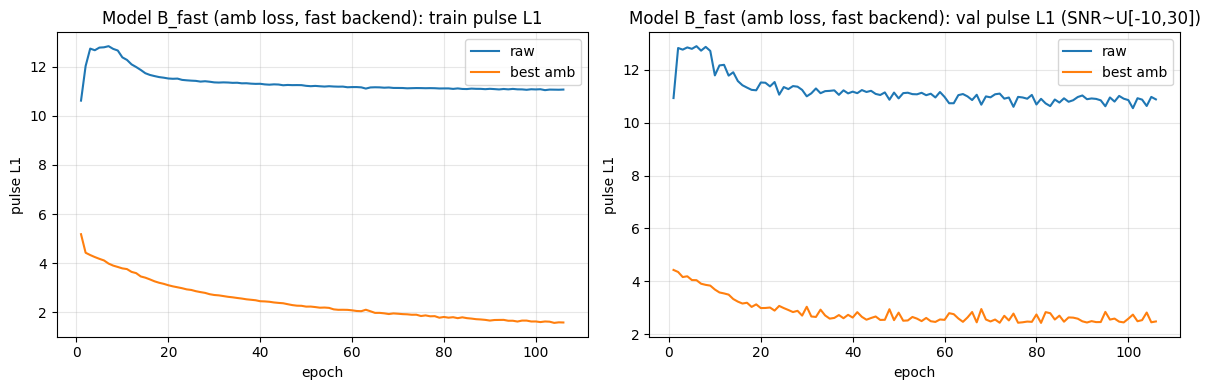

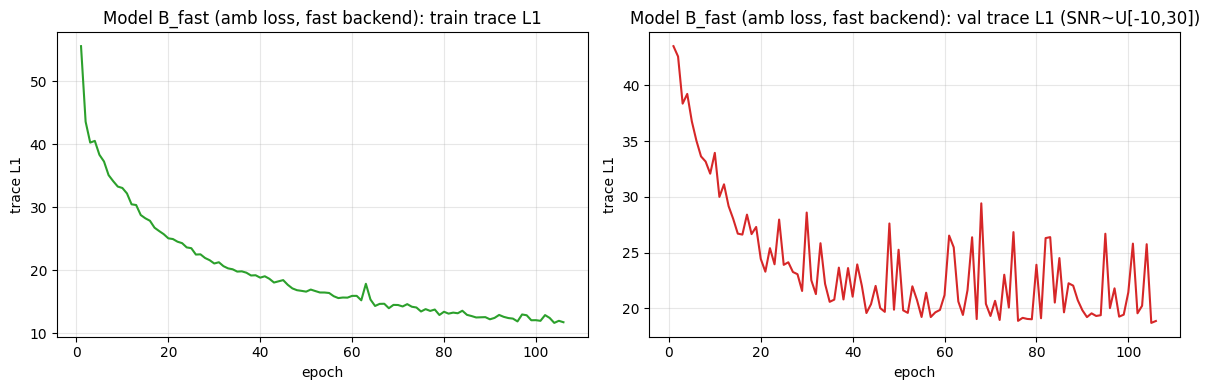

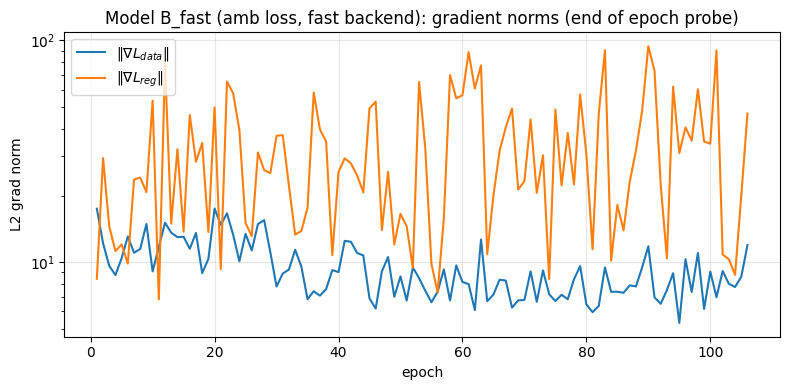

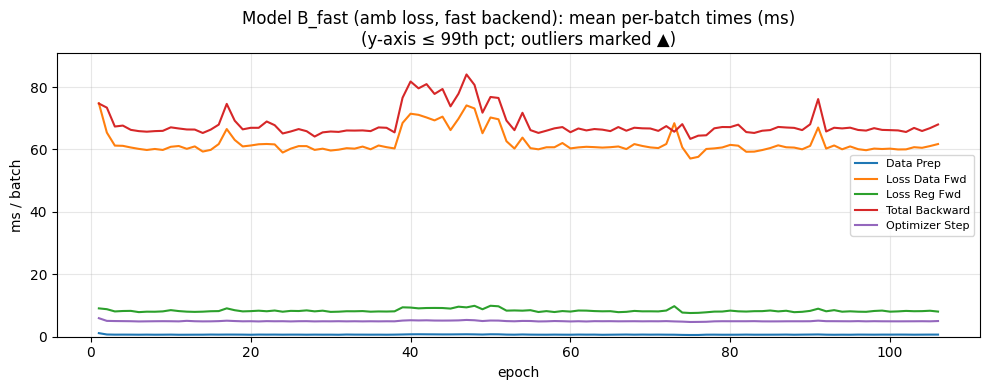

=== Model B_fast: mean±std over epochs (ms/batch) ===
  Data Prep         :    0.678 ±   0.061
  Loss Data Fwd     :   62.131 ±   3.640
  Loss Reg Fwd      :    8.350 ±   0.489
  Total Backward    :   68.270 ±   4.337
  Optimizer Step    :    4.996 ±   0.140

=== Timing comparison: legacy B vs B_fast (mean ms/batch) ===
  Data Prep         : legacy    0.918  fast    0.678  ratio legacy/fast= 1.35
  Loss Data Fwd     : legacy  232.439  fast   62.131  ratio legacy/fast= 3.74
  Loss Reg Fwd      : legacy    9.245  fast    8.350  ratio legacy/fast= 1.11
  Total Backward    : legacy  316.661  fast   68.270  ratio legacy/fast= 4.64
  Optimizer Step    : legacy    5.492  fast    4.996  ratio legacy/fast= 1.10


In [31]:

assert hist_b_fast is not None, "Model B_fast history missing"

plot_pulse_curves(hist_b_fast, "Model B_fast (amb loss, fast backend)")
plot_trace_curves(hist_b_fast, "Model B_fast (amb loss, fast backend)")
plot_grad_norms(hist_b_fast, "Model B_fast (amb loss, fast backend)")
plot_timings(hist_b_fast, "Model B_fast (amb loss, fast backend)")
summarize_timings(hist_b_fast, "Model B_fast")

# Compare mean timings to legacy B if available
path_b_legacy = OUT / "model_b_amb_pulse_loss_history.npz"
hist_b_legacy = diag.load_history(path_b_legacy) if path_b_legacy.exists() else hist_b if "hist_b" in globals() else None
if hist_b_legacy is not None:
    print("\n=== Timing comparison: legacy B vs B_fast (mean ms/batch) ===")
    for k, lab in [
        ("timing_data_prep_sec", "Data Prep"),
        ("timing_loss_data_fwd_sec", "Loss Data Fwd"),
        ("timing_loss_reg_fwd_sec", "Loss Reg Fwd"),
        ("timing_total_backward_sec", "Total Backward"),
        ("timing_optimizer_step_sec", "Optimizer Step"),
    ]:
        a = np.asarray(hist_b_legacy[k]) * 1e3
        b = np.asarray(hist_b_fast[k]) * 1e3
        print(
            f"  {lab:18s}: legacy {a.mean():8.3f}  fast {b.mean():8.3f}  "
            f"ratio legacy/fast={a.mean()/max(b.mean(),1e-9):5.2f}"
        )


### Held-out test SNR sweep — Model A vs Model B_fast

Uses the same test split as before. Legacy B sweep file is **not** overwritten.


skip B_fast sweep; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_b_amb_pulse_loss_fast_test_snr_sweep.npz
Held-out test L1 best-amb: A vs B_fast
   SNR        A   B_fast   A-B_fast
   -10   3.3990   3.4671    -0.0681
    -5   2.7537   2.8022    -0.0485
     0   2.5618   2.6127    -0.0510
     5   2.4872   2.5080    -0.0208
    10   2.4499   2.5039    -0.0539
    15   2.4454   2.5019    -0.0565
    20   2.4406   2.4972    -0.0565
    25   2.4402   2.4938    -0.0536
    30   2.4413   2.4995    -0.0582


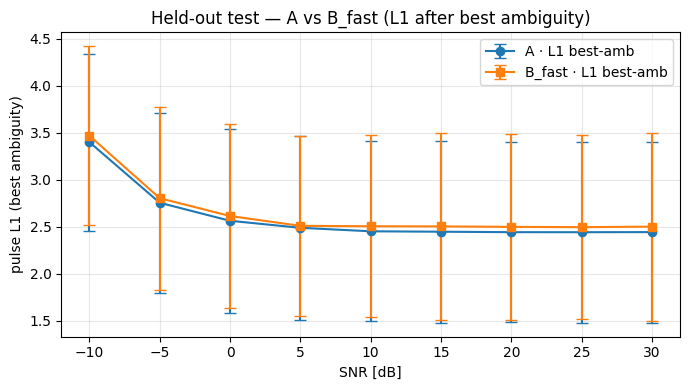

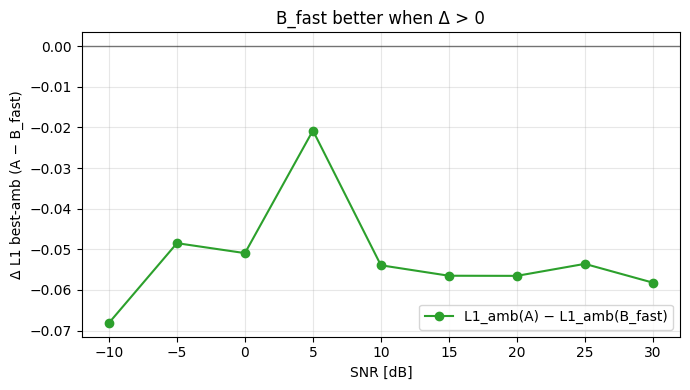

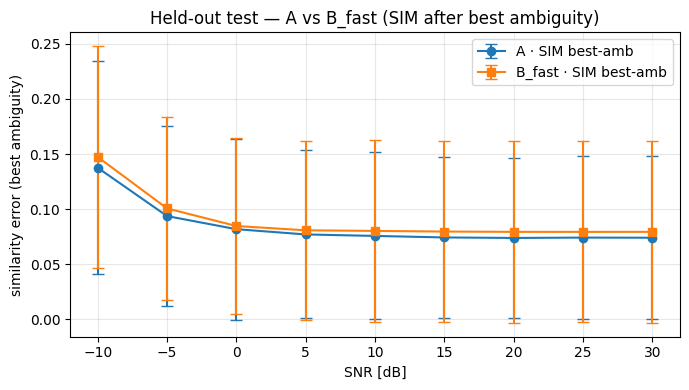

In [32]:

from evaluate_cnn import load_cnn_sweep, plot_metric_curves

tag_a = globals().get("tag_a", "model_a_raw_pulse_loss")
sweep_path_a = OUT / f"{tag_a}_test_snr_sweep.npz"
sweep_path_b_fast = OUT / f"{tag_b_fast}_test_snr_sweep.npz"

if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

if RUN_TEST_SWEEP and (FORCE_TEST_SWEEP_A or not sweep_path_a.exists()):
    print("Running test SNR sweep — Model A...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{tag_a}_model.pt",
        sweep_path_a,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name="data_c_model_a_raw_pulse_loss",
        verbose=True,
    )

if RUN_TEST_SWEEP and (FORCE_TEST_SWEEP_B_FAST or not sweep_path_b_fast.exists()):
    print("Running test SNR sweep — Model B_fast...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{tag_b_fast}_model.pt",
        sweep_path_b_fast,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name="data_c_model_b_amb_pulse_loss_fast",
        verbose=True,
    )
else:
    print(
        "skip B_fast sweep; using",
        sweep_path_b_fast if sweep_path_b_fast.exists() else "(missing)",
    )

sweep_a = load_cnn_sweep(sweep_path_a)
sweep_b_fast = load_cnn_sweep(sweep_path_b_fast)

snr = sweep_a.snr_sweep_db
delta_l1 = np.asarray(sweep_a.cnn_l1_amb_m) - np.asarray(sweep_b_fast.cnn_l1_amb_m)

print("Held-out test L1 best-amb: A vs B_fast")
print(f"{'SNR':>6s} {'A':>8s} {'B_fast':>8s} {'A-B_fast':>10s}")
for i, s in enumerate(snr):
    print(
        f"{float(s):6.0f} {float(sweep_a.cnn_l1_amb_m[i]):8.4f} "
        f"{float(sweep_b_fast.cnn_l1_amb_m[i]):8.4f} {float(delta_l1[i]):10.4f}"
    )

plot_metric_curves(
    snr,
    [
        (sweep_a.cnn_l1_amb_m, sweep_a.cnn_l1_amb_s, "o-", "A · L1 best-amb"),
        (sweep_b_fast.cnn_l1_amb_m, sweep_b_fast.cnn_l1_amb_s, "s-", "B_fast · L1 best-amb"),
    ],
    xlabel="SNR [dB]",
    ylabel="pulse L1 (best ambiguity)",
    title="Held-out test — A vs B_fast (L1 after best ambiguity)",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snr, delta_l1, "o-", color="C2", label="L1_amb(A) − L1_amb(B_fast)")
ax.axhline(0.0, color="k", lw=1, alpha=0.5)
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Δ L1 best-amb (A − B_fast)")
ax.set_title("B_fast better when Δ > 0")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

plot_metric_curves(
    snr,
    [
        (sweep_a.cnn_sim_amb_m, sweep_a.cnn_sim_amb_s, "o-", "A · SIM best-amb"),
        (sweep_b_fast.cnn_sim_amb_m, sweep_b_fast.cnn_sim_amb_s, "s-", "B_fast · SIM best-amb"),
    ],
    xlabel="SNR [dB]",
    ylabel="similarity error (best ambiguity)",
    title="Held-out test — A vs B_fast (SIM after best ambiguity)",
)


## Model A — noisy trace in trace loss + λ sweep

Same Model A protocol (raw pulse L1, Multires 2K, Data C), but the **trace loss** uses the **noisy trace fed to the network** (not the clean trace).

| Item | Value |
|------|-------|
| λ grid | **1, 2, 3, 4, 5** |
| Winner | lowest **val pulse L1 after best ambiguity** |
| Artifacts | `model_a_raw_pulse_loss_noisy_trace_lam{λ}` + winner `model_a_raw_pulse_loss_noisy_trace` |

Compare to original Model A (`model_a_raw_pulse_loss`, λ=3, clean trace in loss).


In [33]:
# --- noisy-trace Model A λ sweep ---
LAM_NOISY_TRACE_GRID = [1.0, 2.0, 3.0, 4.0, 5.0]
RUN_NOISY_TRACE_LAM_SWEEP = True
FORCE_NOISY_TRACE_LAM_SWEEP = False
RUN_NOISY_TRACE_SWEEP = True
FORCE_NOISY_TRACE_SWEEP = False

tag_a_old = "model_a_raw_pulse_loss"
tag_a_new = "model_a_raw_pulse_loss_noisy_trace"

if RUN_NOISY_TRACE_LAM_SWEEP:
    lam_sweep_res = diag.run_model_a_noisy_trace_lambda_sweep(
        LAM_NOISY_TRACE_GRID,
        OUT,
        force=FORCE_NOISY_TRACE_LAM_SWEEP,
        n_train=N_TRAIN,
        n_val=N_VAL,
        n_test=N_TEST,
        seed=SEED,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=DEVICE,
        verbose=True,
        winner_tag=tag_a_new,
    )
    print(json.dumps(lam_sweep_res["summary"], indent=2))
else:
    summary_path = OUT / "model_a_noisy_trace_lambda_sweep_summary.json"
    lam_sweep_res = None
    if summary_path.exists():
        print(summary_path.read_text(encoding="utf-8"))


skip λ=1 (exists): model_a_raw_pulse_loss_noisy_trace_lam1
skip λ=2 (exists): model_a_raw_pulse_loss_noisy_trace_lam2
skip λ=3 (exists): model_a_raw_pulse_loss_noisy_trace_lam3
skip λ=4 (exists): model_a_raw_pulse_loss_noisy_trace_lam4
skip λ=5 (exists): model_a_raw_pulse_loss_noisy_trace_lam5
λ*=5  best val L1-amb=2.3836  winner=model_a_raw_pulse_loss_noisy_trace
{
  "lambda_values": [
    1.0,
    2.0,
    3.0,
    4.0,
    5.0
  ],
  "best_lam": 5.0,
  "best_score": 2.3836146441102026,
  "winner_tag": "model_a_raw_pulse_loss_noisy_trace",
  "per_lam_best_score": {
    "1.0": 2.5722275668382646,
    "2.0": 2.5082624888420106,
    "3.0": 2.396109402179718,
    "4.0": 2.489720569252968,
    "5.0": 2.3836146441102026
  },
  "trace_loss_ref": "noisy",
  "selection_metric": "val_pulse_l1_amb"
}


### λ sweep — train / val pulse L1 (best-amb) per λ


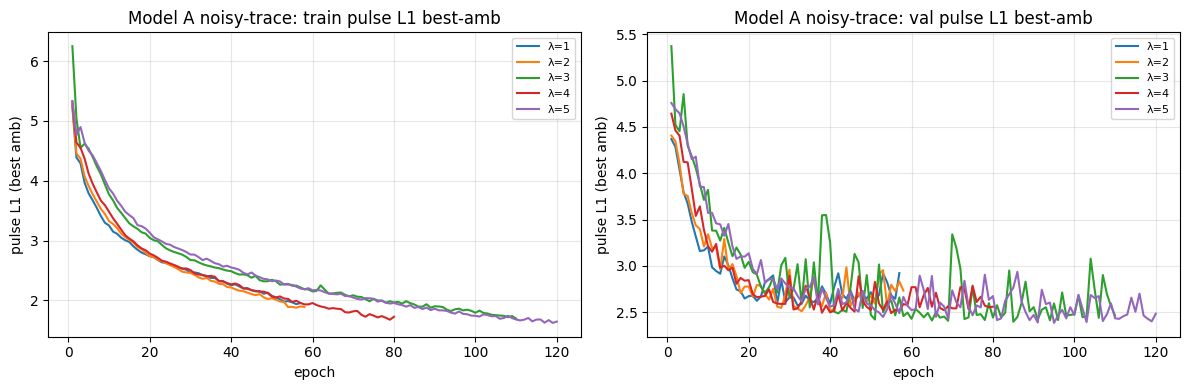

best val L1-amb per λ: {1.0: 2.5722275668382646, 2.0: 2.5082624888420106, 3.0: 2.396109402179718, 4.0: 2.489720569252968, 5.0: 2.3836146441102026}
λ* = 5  (score=2.3836)


In [34]:
def plot_noisy_trace_lambda_curves(lambda_values, title_prefix="Model A noisy-trace"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    best_scores = {}
    for lam in lambda_values:
        tag = diag.model_a_noisy_trace_lambda_tag(lam)
        path = OUT / f"{tag}_history.npz"
        if not path.exists():
            print("missing", path)
            continue
        h = diag.load_history(path)
        ep = np.arange(1, len(h["train_pulse_l1_amb"]) + 1)
        axes[0].plot(ep, h["train_pulse_l1_amb"], label=f"λ={lam:g}")
        axes[1].plot(ep, h["val_pulse_l1_amb"], label=f"λ={lam:g}")
        meta = json.loads((OUT / f"{tag}_meta.json").read_text(encoding="utf-8"))
        best_scores[float(lam)] = float(meta["best_score"])
    axes[0].set_title(f"{title_prefix}: train pulse L1 best-amb")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("pulse L1 (best amb)")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[1].set_title(f"{title_prefix}: val pulse L1 best-amb")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("pulse L1 (best amb)")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    if best_scores:
        lam_star = min(best_scores, key=best_scores.get)
        print("best val L1-amb per λ:", best_scores)
        print(f"λ* = {lam_star:g}  (score={best_scores[lam_star]:.4f})")


plot_noisy_trace_lambda_curves(LAM_NOISY_TRACE_GRID)


### Test SNR sweep — Model A old (clean trace loss) vs new (noisy trace loss)


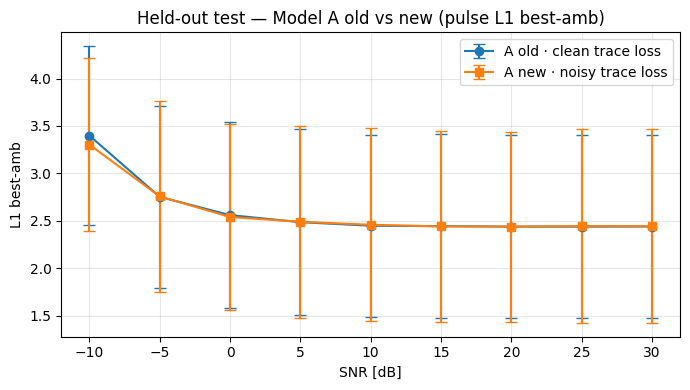

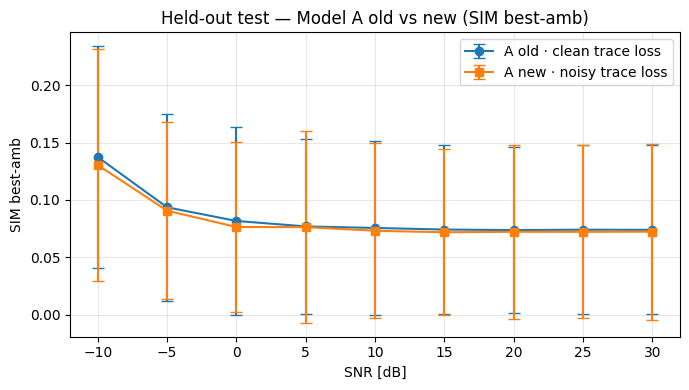

In [35]:
from evaluate_cnn import load_cnn_sweep, plot_metric_curves

sweep_path_old = OUT / f"{tag_a_old}_test_snr_sweep.npz"
sweep_path_new = OUT / f"{tag_a_new}_test_snr_sweep.npz"

if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

if RUN_NOISY_TRACE_SWEEP and (FORCE_NOISY_TRACE_SWEEP or not sweep_path_new.exists()):
    print("Running SNR sweep — Model A noisy-trace winner...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{tag_a_new}_model.pt",
        sweep_path_new,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name="data_c_model_a_noisy_trace",
        verbose=True,
    )

sweep_a_old = load_cnn_sweep(sweep_path_old)
sweep_a_new = load_cnn_sweep(sweep_path_new)

plot_metric_curves(
    sweep_a_old.snr_sweep_db,
    [
        (sweep_a_old.cnn_l1_amb_m, sweep_a_old.cnn_l1_amb_s, "o-", "A old · clean trace loss"),
        (sweep_a_new.cnn_l1_amb_m, sweep_a_new.cnn_l1_amb_s, "s-", "A new · noisy trace loss"),
    ],
    xlabel="SNR [dB]",
    ylabel="L1 best-amb",
    title="Held-out test — Model A old vs new (pulse L1 best-amb)",
)
plot_metric_curves(
    sweep_a_old.snr_sweep_db,
    [
        (sweep_a_old.cnn_sim_amb_m, sweep_a_old.cnn_sim_amb_s, "o-", "A old · clean trace loss"),
        (sweep_a_new.cnn_sim_amb_m, sweep_a_new.cnn_sim_amb_s, "s-", "A new · noisy trace loss"),
    ],
    xlabel="SNR [dB]",
    ylabel="SIM best-amb",
    title="Held-out test — Model A old vs new (SIM best-amb)",
)


### Example — noisy test sample @ 10 dB: Model A old vs new


Drew test sample index 77 / 511
Example @ SNR=10 dB
  A old: raw=2.1015  best-amb=2.0326
  A new: raw=2.2617  best-amb=2.2617


C:\Users\SharonLab\AppData\Local\Temp\ipykernel_30388\1274192545.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


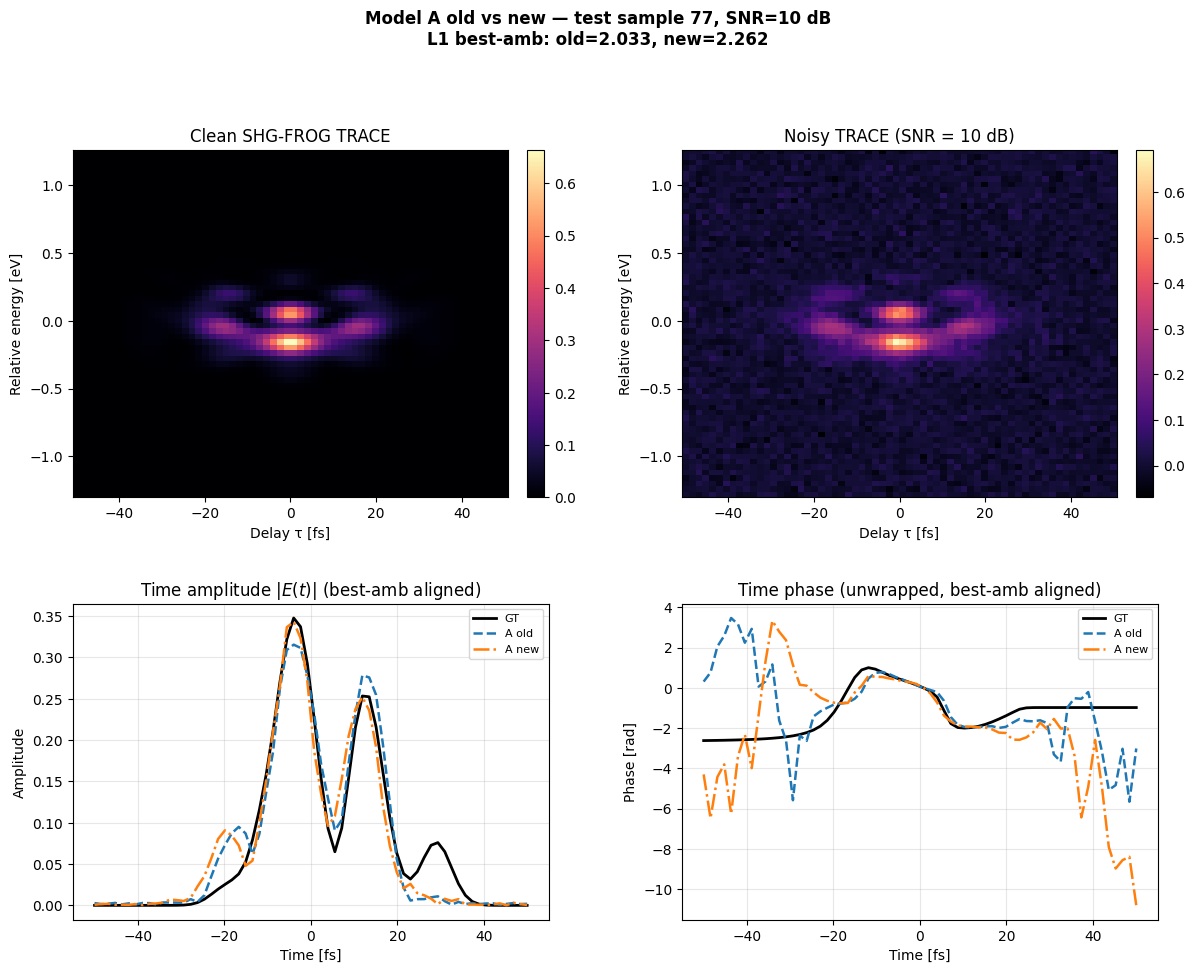

In [39]:
from data_generation import phase_t_unwrapped_at_zero, stochastic_pulse_config_data_c
from frog_reconstruction_model import extract_pulse_prediction
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    prepare_frog_trace_for_plot,
    pack_complex_field,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn

EXAMPLE_SNR_DB = 10.0

cfg = stochastic_pulse_config_data_c(n=64)
t_axis = np.linspace(-cfg.t_total_fs / 2.0, cfg.t_total_fs / 2.0, cfg.n)
dt = cfg.t_total_fs / max(cfg.n - 1, 1)

if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

_test_ds = test_loader.dataset
EXAMPLE_INDEX = int(np.random.randint(0, len(_test_ds)))
I_clean, E_true_packed = _test_ds[EXAMPLE_INDEX]
I_clean = I_clean.to(DEVICE)
E_true_packed = E_true_packed.to(DEVICE)
I_noisy = add_trace_noise_awgn(I_clean.unsqueeze(0), EXAMPLE_SNR_DB).squeeze(0)
print(f"Drew test sample index {EXAMPLE_INDEX} / {len(_test_ds) - 1}")

model_a_old = diag.load_trained_multires(OUT / f"{tag_a_old}_model.pt", device=DEVICE)
model_a_new = diag.load_trained_multires(OUT / f"{tag_a_new}_model.pt", device=DEVICE)

with torch.no_grad():
    x = I_noisy.unsqueeze(0).unsqueeze(0)
    E_old = extract_pulse_prediction(model_a_old(x)).squeeze(0).cpu().numpy()
    E_new = extract_pulse_prediction(model_a_new(x)).squeeze(0).cpu().numpy()

e_true = unpack_packed_field(E_true_packed.detach().cpu().numpy())
e_old = unpack_packed_field(E_old)
e_new = unpack_packed_field(E_new)
e_old_al = best_l1_ambiguity_field(e_old, e_true)
e_new_al = best_l1_ambiguity_field(e_new, e_true)

l1_old_amb = best_l1_ambiguity(e_old, e_true)
l1_new_amb = best_l1_ambiguity(e_new, e_true)
l1_old_raw = float(np.abs(pack_complex_field(e_old) - pack_complex_field(e_true)).sum())
l1_new_raw = float(np.abs(pack_complex_field(e_new) - pack_complex_field(e_true)).sum())
print(
    f"Example @ SNR={EXAMPLE_SNR_DB:.0f} dB\n"
    f"  A old: raw={l1_old_raw:.4f}  best-amb={l1_old_amb:.4f}\n"
    f"  A new: raw={l1_new_raw:.4f}  best-amb={l1_new_amb:.4f}"
)

phase_true = phase_t_unwrapped_at_zero(e_true)
_, phase_old = unwrap_phases_for_overlay(e_old_al, e_true)
_, phase_new = unwrap_phases_for_overlay(e_new_al, e_true)

trace_clean, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_clean.detach().cpu().numpy(), num_points=cfg.n, dt=dt
)
trace_noisy, _, _ = prepare_frog_trace_for_plot(
    I_noisy.detach().cpu().numpy(), num_points=cfg.n, dt=dt
)
h_ev_fs = 4.135667696
energy_plot = omega_plot * h_ev_fs / (2.0 * np.pi)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0], hspace=0.32, wspace=0.28)

ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(
    trace_clean,
    origin="lower",
    aspect="auto",
    extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
    cmap="magma",
)
ax0.set_title("Clean SHG-FROG TRACE")
ax0.set_xlabel("Delay τ [fs]")
ax0.set_ylabel("Relative energy [eV]")
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(
    trace_noisy,
    origin="lower",
    aspect="auto",
    extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
    cmap="magma",
)
ax1.set_title(f"Noisy TRACE (SNR = {EXAMPLE_SNR_DB:.0f} dB)")
ax1.set_xlabel("Delay τ [fs]")
ax1.set_ylabel("Relative energy [eV]")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t_axis, np.abs(e_true), "k-", lw=2, label="GT")
ax2.plot(t_axis, np.abs(e_old_al), "C0--", lw=1.8, label="A old")
ax2.plot(t_axis, np.abs(e_new_al), "C1-.", lw=1.8, label="A new")
ax2.set_title(r"Time amplitude $|E(t)|$ (best-amb aligned)")
ax2.set_xlabel("Time [fs]")
ax2.set_ylabel("Amplitude")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_axis, phase_true, "k-", lw=2, label="GT")
ax3.plot(t_axis, phase_old, "C0--", lw=1.8, label="A old")
ax3.plot(t_axis, phase_new, "C1-.", lw=1.8, label="A new")
ax3.set_title(r"Time phase (unwrapped, best-amb aligned)")
ax3.set_xlabel("Time [fs]")
ax3.set_ylabel("Phase [rad]")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    f"Model A old vs new — test sample {EXAMPLE_INDEX}, SNR={EXAMPLE_SNR_DB:.0f} dB\n"
    f"L1 best-amb: old={l1_old_amb:.3f}, new={l1_new_amb:.3f}",
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


## Model A — best-ambiguity inference timing (legacy vs fast)

Uses the **existing** Model A checkpoint (`model_a_raw_pulse_loss_model.pt`). No retraining.

Protocol:
1. Forward pass once → cache `E_pred` / `E_true` per batch.
2. Time **only** the best-ambiguity step on the same cached predictions:
   - **legacy torch** (per-sample NumPy loop in `align_pred_best_l1_ambiguity_torch`)
   - **legacy numpy** (same path as `evaluate_cnn` SNR sweep: `best_l1_ambiguity` per sample)
   - **fast torch** (batched GPU + FFT)

Splits: **validation** (200, SNR U[−10, 30]) and **test SNR sweep** (512 × 9 SNR points).


In [40]:
RUN_AMB_INFERENCE_BENCH = True
FORCE_AMB_INFERENCE_BENCH = False

tag_a_old = globals().get("tag_a_old", "model_a_raw_pulse_loss")
amb_bench_path = OUT / "model_a_amb_inference_benchmark.json"

if "val_loader_amb" not in globals():
    from data_generation import stochastic_pulse_config_data_c
    from dataset_utils import build_stochastic_frog_dataloaders

    _bundle = build_stochastic_frog_dataloaders(
        n_train=N_TRAIN,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=64,
        seed=SEED,
        device=DEVICE,
        grid=stochastic_pulse_config_data_c(n=64),
        canonicalize_mode="t0",
    )
    val_loader_amb = diag.subset_loader(_bundle.val_loader, N_VAL)
    test_loader_amb = diag.subset_loader(_bundle.test_loader, N_TEST)

if RUN_AMB_INFERENCE_BENCH and (FORCE_AMB_INFERENCE_BENCH or not amb_bench_path.exists()):
    print("Running ambiguity inference benchmark on Model A (no retrain)...")
    amb_bench = diag.benchmark_ambiguity_inference(
        OUT / f"{tag_a_old}_model.pt",
        val_loader=val_loader_amb,
        test_loader=test_loader_amb,
        device=DEVICE,
        val_snr_db_range=(-10.0, 30.0),
        test_snr_sweep_db=SNR_SWEEP_DB,
        n_warmup=2,
        n_repeat=5,
        seed=SEED,
    )
    diag.save_ambiguity_inference_benchmark(amb_bench, amb_bench_path)
else:
    amb_bench = json.loads(amb_bench_path.read_text(encoding="utf-8"))
    print("loaded", amb_bench_path)

print(json.dumps(amb_bench["validation"], indent=2))
print("--- test sweep totals ---")
print(json.dumps({k: amb_bench["test_snr_sweep"][k] for k in (
    "total_samples", "legacy_torch_ms_per_sample", "fast_torch_ms_per_sample",
    "legacy_numpy_ms_per_sample", "speedup_legacy_torch_vs_fast",
    "speedup_legacy_numpy_vs_fast",
)}, indent=2))


loaded d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_amb_inference_benchmark.json
{
  "n_samples": 200,
  "snr_db_range": [
    -10.0,
    30.0
  ],
  "verify": {
    "n_checked": 64,
    "max_abs_l1_diff_legacy_vs_fast": 0.0
  },
  "forward": {
    "mean_sec": 0.053328340011648837,
    "std_sec": 0.00025200908930759407,
    "min_sec": 0.05310520005878061,
    "max_sec": 0.05380630004219711
  },
  "legacy_torch": {
    "mean_sec": 0.6597524000331759,
    "std_sec": 0.02040424030952784,
    "min_sec": 0.6363575001014397,
    "max_sec": 0.6923562000738457
  },
  "fast_torch": {
    "mean_sec": 0.16040358000900595,
    "std_sec": 0.014013537920986679,
    "min_sec": 0.13282940001226962,
    "max_sec": 0.17058069992344826
  },
  "legacy_numpy": {
    "mean_sec": 0.5640211000107229,
    "std_sec": 0.03542561289241042,
    "min_sec": 0.5337105999933556,
    "max_sec": 0.6332398999948055
  },
  "forward_ms_per_sample": 0.26664170005824

stage                                       ms/sample        n
Val forward                                     0.267      200
Val amb legacy (torch)                          3.299      200
Val amb legacy (numpy, SNR sweep path)          2.820      200
Val amb fast (torch)                            0.802      200
Test amb legacy (torch)                         3.243     4608
Test amb legacy (numpy)                         2.740     4608
Test amb fast (torch)                           1.012     4608

Val speedup legacy→fast: torch 4.11×, numpy 3.52×
Test SNR sweep speedup legacy→fast: torch 3.21×, numpy 2.71×
L1 check (legacy vs fast, n=64): max |Δ| = 0.00e+00


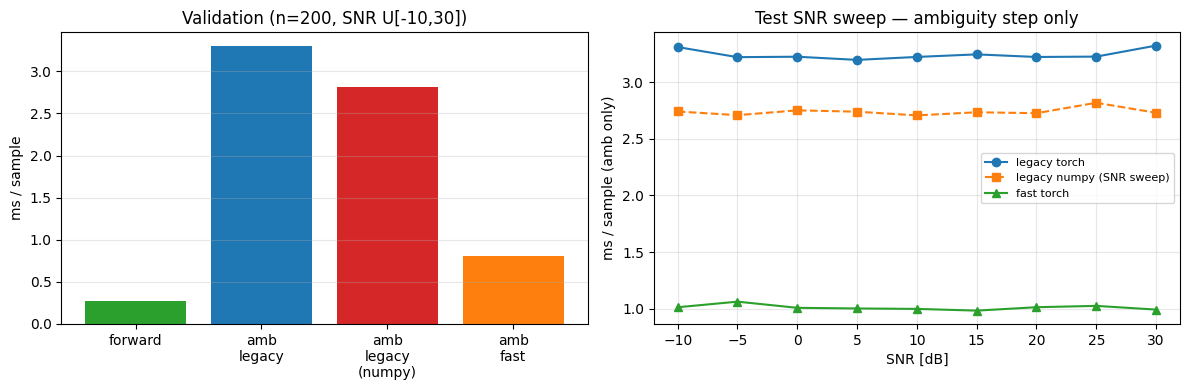

In [41]:
def _print_amb_bench_table(amb_bench: dict) -> None:
    v = amb_bench["validation"]
    t = amb_bench["test_snr_sweep"]
    rows = [
        ("Val forward", v["forward_ms_per_sample"], v["n_samples"]),
        ("Val amb legacy (torch)", v["legacy_torch_ms_per_sample"], v["n_samples"]),
        ("Val amb legacy (numpy, SNR sweep path)", v["legacy_numpy_ms_per_sample"], v["n_samples"]),
        ("Val amb fast (torch)", v["fast_torch_ms_per_sample"], v["n_samples"]),
        ("Test amb legacy (torch)", t["legacy_torch_ms_per_sample"], t["total_samples"]),
        ("Test amb legacy (numpy)", t["legacy_numpy_ms_per_sample"], t["total_samples"]),
        ("Test amb fast (torch)", t["fast_torch_ms_per_sample"], t["total_samples"]),
    ]
    print(f"{'stage':40s} {'ms/sample':>12s} {'n':>8s}")
    for name, ms, n in rows:
        print(f"{name:40s} {ms:12.3f} {n:8d}")
    print()
    print(
        f"Val speedup legacy→fast: torch {v['speedup_legacy_torch_vs_fast']:.2f}×, "
        f"numpy {v['speedup_legacy_numpy_vs_fast']:.2f}×"
    )
    print(
        f"Test SNR sweep speedup legacy→fast: torch {t['speedup_legacy_torch_vs_fast']:.2f}×, "
        f"numpy {t['speedup_legacy_numpy_vs_fast']:.2f}×"
    )
    print(
        f"L1 check (legacy vs fast, n={v['verify']['n_checked']}): "
        f"max |Δ| = {v['verify']['max_abs_l1_diff_legacy_vs_fast']:.2e}"
    )


_print_amb_bench_table(amb_bench)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Val bar chart
v = amb_bench["validation"]
labels = ["forward", "amb\nlegacy", "amb\nlegacy\n(numpy)", "amb\nfast"]
vals = [
    v["forward_ms_per_sample"],
    v["legacy_torch_ms_per_sample"],
    v["legacy_numpy_ms_per_sample"],
    v["fast_torch_ms_per_sample"],
]
colors = ["C2", "C0", "C3", "C1"]
axes[0].bar(labels, vals, color=colors)
axes[0].set_ylabel("ms / sample")
axes[0].set_title(f"Validation (n={v['n_samples']}, SNR U[-10,30])")
axes[0].grid(True, axis="y", alpha=0.3)

# Test per-SNR ambiguity only
per = amb_bench["test_snr_sweep"]["per_snr"]
snrs = [p["snr_db"] for p in per]
leg_ms = [p["legacy_torch_mean_sec"] / p["n_samples"] * 1e3 for p in per]
fast_ms = [p["fast_torch_mean_sec"] / p["n_samples"] * 1e3 for p in per]
np_ms = [p["legacy_numpy_mean_sec"] / p["n_samples"] * 1e3 for p in per]
axes[1].plot(snrs, leg_ms, "o-", label="legacy torch")
axes[1].plot(snrs, np_ms, "s--", label="legacy numpy (SNR sweep)")
axes[1].plot(snrs, fast_ms, "^-", label="fast torch")
axes[1].set_xlabel("SNR [dB]")
axes[1].set_ylabel("ms / sample (amb only)")
axes[1].set_title("Test SNR sweep — ambiguity step only")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Model A — sparse train SNR {0, 15, 30} dB: λ=3 vs λ=0

Same Model A protocol (raw pulse L1, Data C, Multires 2K), but **train SNR** is sampled from the discrete set **{0, 15, 30} dB** instead of continuous U[0, 30].

| Item | Value |
|------|-------|
| Val | unchanged: SNR U[−10, 30] |
| Test | unchanged SNR sweep |
| Model A₃ | λ=**3**, clean-trace physics loss |
| Model A₀ | λ=**0** (no TRACE loss) |

Artifacts: `model_a_raw_sparse_snr_lam3_*`, `model_a_raw_sparse_snr_lam0_*`


In [46]:
# --- Model A sparse train SNR: λ=3 vs λ=0 ---
TRAIN_SNR_SPARSE_DB = [0.0, 15.0, 30.0]
RUN_TRAIN_A_SPARSE = True
FORCE_TRAIN_A_SPARSE = False
RUN_TEST_SWEEP_A_SPARSE = True
FORCE_TEST_SWEEP_A_SPARSE = False

tag_a_sparse_lam3 = "model_a_raw_sparse_snr_lam3"
tag_a_sparse_lam0 = "model_a_raw_sparse_snr_lam0"

def _train_or_load_sparse(tag: str, lam: float):
    path = OUT / f"{tag}_history.npz"
    if RUN_TRAIN_A_SPARSE and (FORCE_TRAIN_A_SPARSE or not path.exists()):
        print(f"Training {tag} (λ={lam:g}, train SNR ∈ {TRAIN_SNR_SPARSE_DB})...")
        res = diag.train_data_c_amb_diagnostics(
            pulse_loss_mode="raw",
            lam=float(lam),
            n_train=N_TRAIN,
            n_val=N_VAL,
            n_test=N_TEST,
            seed=SEED,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=DEVICE,
            verbose=True,
            train_snr_db_values=TRAIN_SNR_SPARSE_DB,
            val_snr_db_range=(-10.0, 30.0),
            trace_loss_ref="clean",
        )
        diag.save_run_artifacts(res, OUT, tag)
        print("saved", tag, "best_epoch", res["best_epoch"], "best", res["best_score"])
        return res
    print("skip", tag, "using", path if path.exists() else "(missing)")
    return None

_train_or_load_sparse(tag_a_sparse_lam3, 3.0)
_train_or_load_sparse(tag_a_sparse_lam0, 0.0)

hist_a_s3 = diag.load_history(OUT / f"{tag_a_sparse_lam3}_history.npz")
hist_a_s0 = diag.load_history(OUT / f"{tag_a_sparse_lam0}_history.npz")
meta_a_s3 = json.loads((OUT / f"{tag_a_sparse_lam3}_meta.json").read_text(encoding="utf-8"))
meta_a_s0 = json.loads((OUT / f"{tag_a_sparse_lam0}_meta.json").read_text(encoding="utf-8"))
print("λ=3", json.dumps(meta_a_s3, indent=2))
print("λ=0", json.dumps(meta_a_s0, indent=2))


skip model_a_raw_sparse_snr_lam3 using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_sparse_snr_lam3_history.npz
skip model_a_raw_sparse_snr_lam0 using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_sparse_snr_lam0_history.npz
λ=3 {
  "best_epoch": 113,
  "best_score": 2.4156701430678367,
  "stopped_epoch": 138,
  "lam": 3.0,
  "trace_scale": 7.780382317804131,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",
  "trace_loss_ref": "clean",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "train_snr_db_values": [
    0.0,
    15.0,
    30.0
  ],
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "n_train": 2048,
  "n_val": 200,
  "seed": 0
}
λ=0 {
  "best_epoch": 24,
  "best_score": 3.0223474687337877,
  "stopped_epoch": 49,
  "lam": 0.0,
  "trace_scale": 7.880736684576619,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",


### Sparse-SNR Model A — training / validation curves (λ=3 vs λ=0)


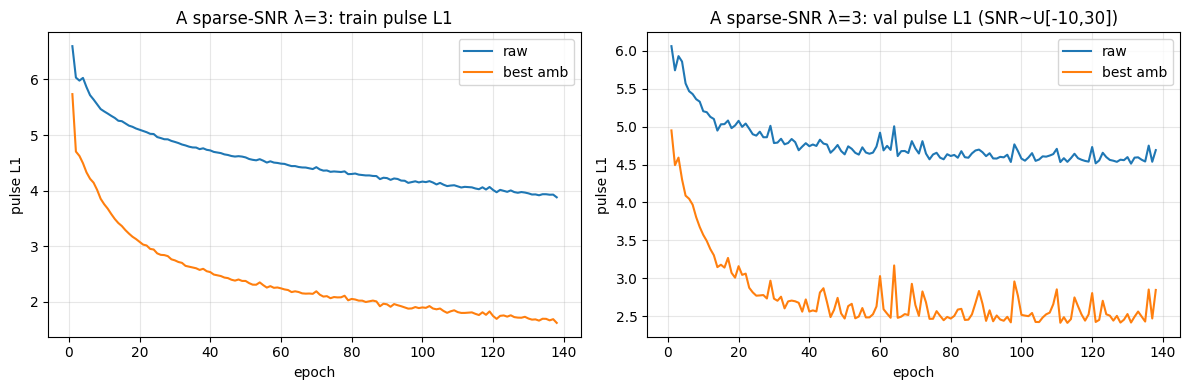

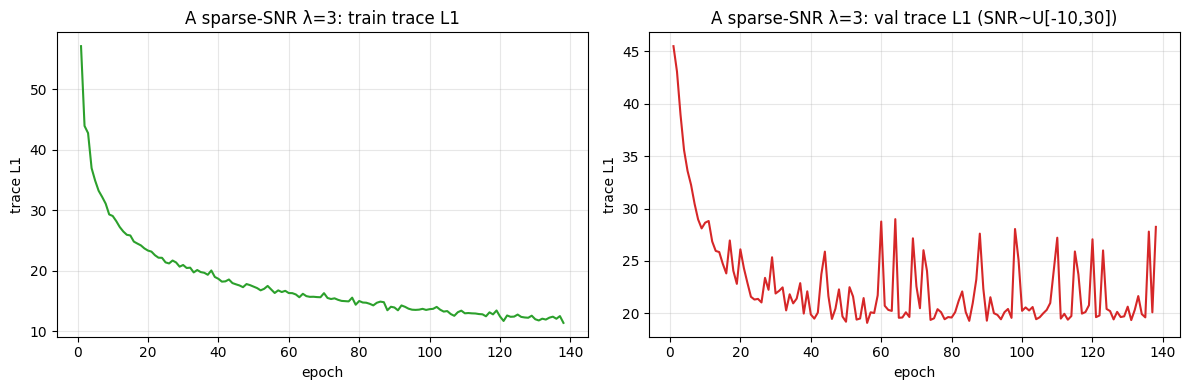

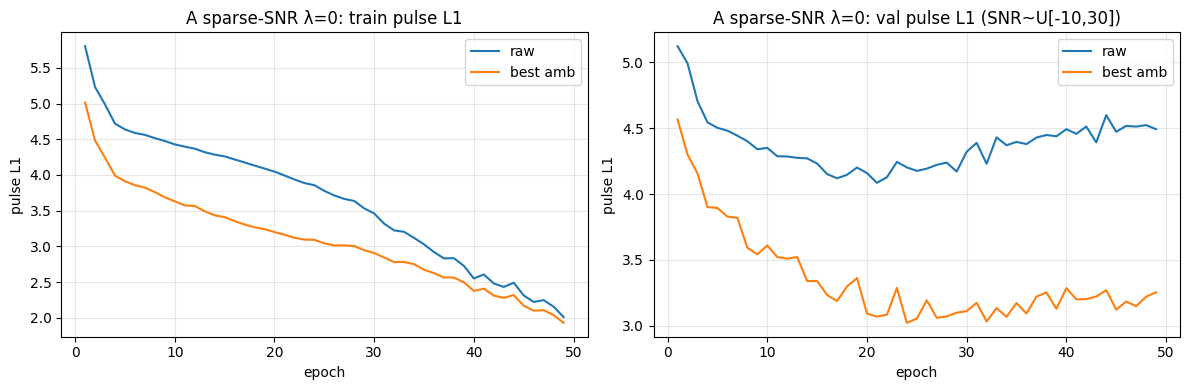

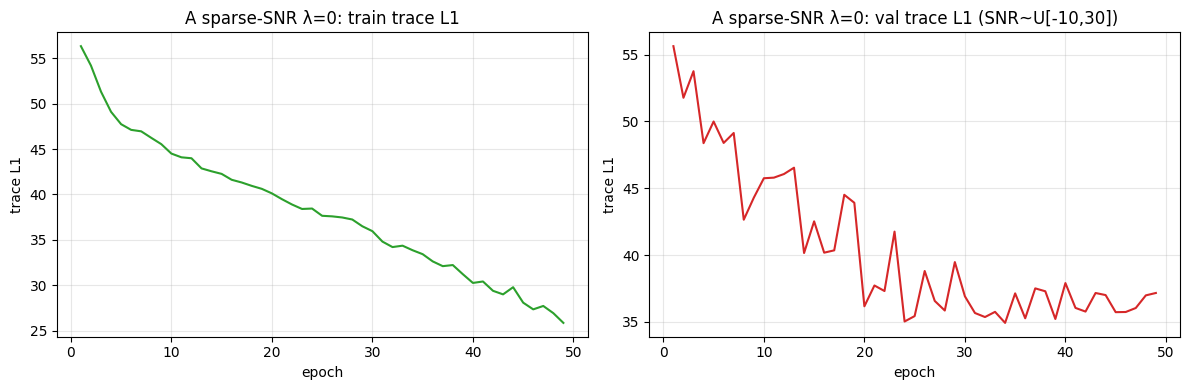

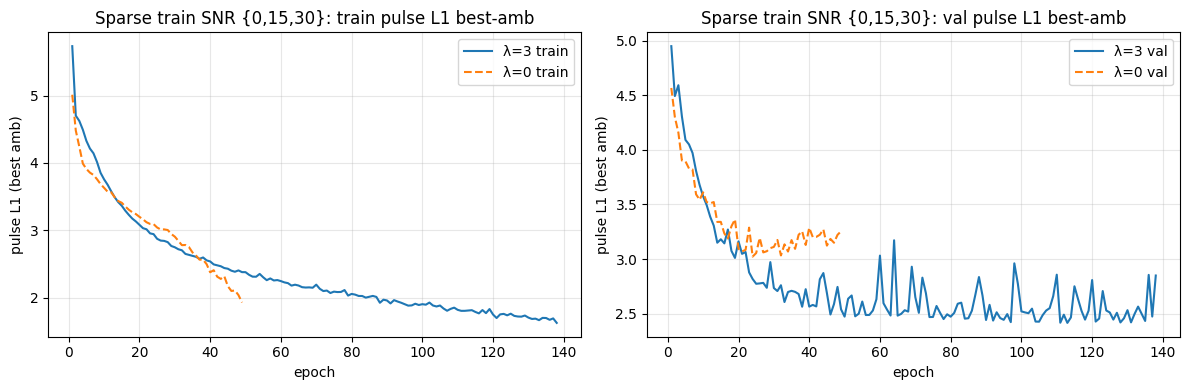

In [47]:
plot_pulse_curves(hist_a_s3, "A sparse-SNR λ=3")
plot_trace_curves(hist_a_s3, "A sparse-SNR λ=3")
plot_pulse_curves(hist_a_s0, "A sparse-SNR λ=0")
# λ=0: trace L1 still logged (diagnostic), not used in the loss
plot_trace_curves(hist_a_s0, "A sparse-SNR λ=0")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name, ls in [
    (hist_a_s3, "λ=3", "-"),
    (hist_a_s0, "λ=0", "--"),
]:
    ep = _epochs(hist["val_pulse_l1_amb"])
    axes[0].plot(ep, hist["train_pulse_l1_amb"], ls=ls, label=f"{name} train")
    axes[1].plot(ep, hist["val_pulse_l1_amb"], ls=ls, label=f"{name} val")
axes[0].set_title("Sparse train SNR {0,15,30}: train pulse L1 best-amb")
axes[1].set_title("Sparse train SNR {0,15,30}: val pulse L1 best-amb")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.set_ylabel("pulse L1 (best amb)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Held-out test SNR sweep — sparse-SNR A (λ=3 / λ=0) vs Model A old

Compare against the original Model A from the start of the notebook (`model_a_raw_pulse_loss`: λ=3, train SNR U[0, 30]).


   SNR      A old   sparse λ=3   sparse λ=0   Δ(3−old)     Δ(0−3)
   -10     3.3990       4.1130       3.5618     0.7141    -0.5512
    -5     2.7537       2.7374       3.2845    -0.0163     0.5471
     0     2.5618       2.5599       3.1489    -0.0019     0.5890
     5     2.4872       2.4626       3.0968    -0.0246     0.6342
    10     2.4499       2.4606       3.0890     0.0107     0.6284
    15     2.4454       2.4546       3.0930     0.0092     0.6384
    20     2.4406       2.4497       3.0868     0.0090     0.6371
    25     2.4402       2.4499       3.0846     0.0097     0.6348
    30     2.4413       2.4489       3.0850     0.0076     0.6361


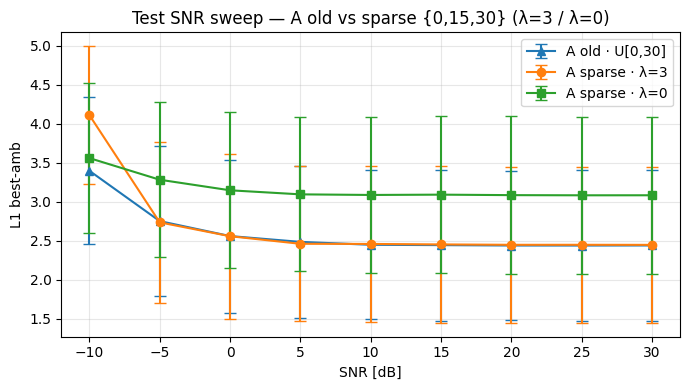

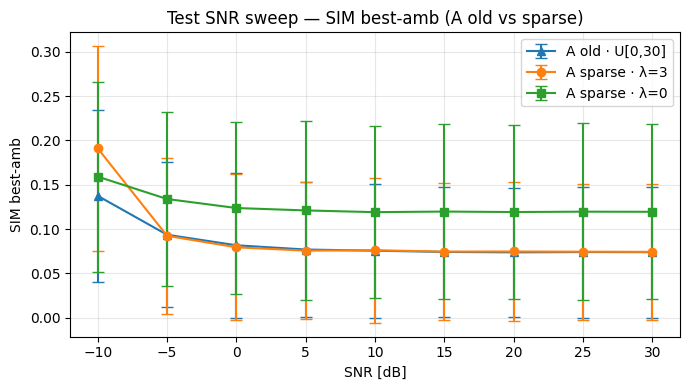

In [49]:
from evaluate_cnn import load_cnn_sweep, plot_metric_curves

if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

tag_a_old = globals().get("tag_a", globals().get("tag_a_old", "model_a_raw_pulse_loss"))
sweep_path_a_old = OUT / f"{tag_a_old}_test_snr_sweep.npz"
sweep_path_s3 = OUT / f"{tag_a_sparse_lam3}_test_snr_sweep.npz"
sweep_path_s0 = OUT / f"{tag_a_sparse_lam0}_test_snr_sweep.npz"

if not sweep_path_a_old.exists():
    raise FileNotFoundError(
        f"Missing Model A old sweep: {sweep_path_a_old} "
        "(run the early Held-out test SNR sweep cell first)."
    )

for tag, path in [
    (tag_a_sparse_lam3, sweep_path_s3),
    (tag_a_sparse_lam0, sweep_path_s0),
]:
    if RUN_TEST_SWEEP_A_SPARSE and (FORCE_TEST_SWEEP_A_SPARSE or not path.exists()):
        print("Running SNR sweep —", tag)
        diag.run_and_save_test_snr_sweep(
            OUT / f"{tag}_model.pt",
            path,
            test_loader=test_loader,
            snr_sweep_db=SNR_SWEEP_DB,
            device=DEVICE,
            experiment_name=f"data_c_{tag}",
            verbose=True,
        )

sweep_a_old = load_cnn_sweep(sweep_path_a_old)
sweep_s3 = load_cnn_sweep(sweep_path_s3)
sweep_s0 = load_cnn_sweep(sweep_path_s0)

print(
    f"{'SNR':>6} {'A old':>10} {'sparse λ=3':>12} {'sparse λ=0':>12} "
    f"{'Δ(3−old)':>10} {'Δ(0−3)':>10}"
)
for i, snr in enumerate(sweep_s3.snr_sweep_db):
    a_old = float(sweep_a_old.cnn_l1_amb_m[i])
    a3 = float(sweep_s3.cnn_l1_amb_m[i])
    a0 = float(sweep_s0.cnn_l1_amb_m[i])
    print(
        f"{float(snr):6.0f} {a_old:10.4f} {a3:12.4f} {a0:12.4f} "
        f"{a3 - a_old:10.4f} {a0 - a3:10.4f}"
    )

plot_metric_curves(
    sweep_s3.snr_sweep_db,
    [
        (sweep_a_old.cnn_l1_amb_m, sweep_a_old.cnn_l1_amb_s, "^-", "A old · U[0,30]"),
        (sweep_s3.cnn_l1_amb_m, sweep_s3.cnn_l1_amb_s, "o-", "A sparse · λ=3"),
        (sweep_s0.cnn_l1_amb_m, sweep_s0.cnn_l1_amb_s, "s-", "A sparse · λ=0"),
    ],
    xlabel="SNR [dB]",
    ylabel="L1 best-amb",
    title="Test SNR sweep — A old vs sparse {0,15,30} (λ=3 / λ=0)",
)
plot_metric_curves(
    sweep_s3.snr_sweep_db,
    [
        (sweep_a_old.cnn_sim_amb_m, sweep_a_old.cnn_sim_amb_s, "^-", "A old · U[0,30]"),
        (sweep_s3.cnn_sim_amb_m, sweep_s3.cnn_sim_amb_s, "o-", "A sparse · λ=3"),
        (sweep_s0.cnn_sim_amb_m, sweep_s0.cnn_sim_amb_s, "s-", "A sparse · λ=0"),
    ],
    xlabel="SNR [dB]",
    ylabel="SIM best-amb",
    title="Test SNR sweep — SIM best-amb (A old vs sparse)",
)


## Model A — sparse train **and** val SNR {0, 15, 30} dB: λ=3 vs λ=0

Same as the previous sparse-SNR chapter, except **validation** also samples TRACE noise from **{0, 15, 30} dB** only (matched to train), instead of U[-10, 30].

| Item | Value |
|------|-------|
| Train | SNR ∈ {0, 15, 30} |
| Val | SNR ∈ {0, 15, 30} (early-stop on val pulse L1 best-amb) |
| Test | unchanged SNR sweep |
| Model A₃ | λ=**3**, clean-trace physics loss |
| Model A₀ | λ=**0** (no TRACE loss) |

Artifacts: `model_a_raw_sparse_snr_tv_lam3_*`, `model_a_raw_sparse_snr_tv_lam0_*`


In [52]:
# --- Model A sparse train+val SNR {0,15,30}: λ=3 vs λ=0 ---
TRAIN_VAL_SNR_SPARSE_DB = [0.0, 15.0, 30.0]
RUN_TRAIN_A_SPARSE_TV = True
FORCE_TRAIN_A_SPARSE_TV = False
RUN_TEST_SWEEP_A_SPARSE_TV = True
FORCE_TEST_SWEEP_A_SPARSE_TV = False

tag_a_sparse_tv_lam3 = "model_a_raw_sparse_snr_tv_lam3"
tag_a_sparse_tv_lam0 = "model_a_raw_sparse_snr_tv_lam0"

def _train_or_load_sparse_tv(tag: str, lam: float):
    path = OUT / f"{tag}_history.npz"
    if RUN_TRAIN_A_SPARSE_TV and (FORCE_TRAIN_A_SPARSE_TV or not path.exists()):
        print(
            f"Training {tag} (λ={lam:g}, train+val SNR ∈ {TRAIN_VAL_SNR_SPARSE_DB})..."
        )
        res = diag.train_data_c_amb_diagnostics(
            pulse_loss_mode="raw",
            lam=float(lam),
            n_train=N_TRAIN,
            n_val=N_VAL,
            n_test=N_TEST,
            seed=SEED,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=DEVICE,
            verbose=True,
            train_snr_db_values=TRAIN_VAL_SNR_SPARSE_DB,
            val_snr_db_values=TRAIN_VAL_SNR_SPARSE_DB,
            val_snr_db_range=(0.0, 30.0),
            trace_loss_ref="clean",
        )
        diag.save_run_artifacts(res, OUT, tag)
        print("saved", tag, "best_epoch", res["best_epoch"], "best", res["best_score"])
        return res
    print("skip", tag, "using", path if path.exists() else "(missing)")
    return None

_train_or_load_sparse_tv(tag_a_sparse_tv_lam3, 3.0)
_train_or_load_sparse_tv(tag_a_sparse_tv_lam0, 0.0)

hist_a_tv3 = diag.load_history(OUT / f"{tag_a_sparse_tv_lam3}_history.npz")
hist_a_tv0 = diag.load_history(OUT / f"{tag_a_sparse_tv_lam0}_history.npz")
meta_a_tv3 = json.loads((OUT / f"{tag_a_sparse_tv_lam3}_meta.json").read_text(encoding="utf-8"))
meta_a_tv0 = json.loads((OUT / f"{tag_a_sparse_tv_lam0}_meta.json").read_text(encoding="utf-8"))
print("λ=3", json.dumps(meta_a_tv3, indent=2))
print("λ=0", json.dumps(meta_a_tv0, indent=2))


skip model_a_raw_sparse_snr_tv_lam3 using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_sparse_snr_tv_lam3_history.npz
skip model_a_raw_sparse_snr_tv_lam0 using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\data_c_amb_loss_diagnostics\model_a_raw_sparse_snr_tv_lam0_history.npz
λ=3 {
  "best_epoch": 68,
  "best_score": 2.3656232276558877,
  "stopped_epoch": 93,
  "lam": 3.0,
  "trace_scale": 7.855795416234488,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",
  "trace_loss_ref": "clean",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "train_snr_db_values": [
    0.0,
    15.0,
    30.0
  ],
  "val_snr_db_range": [
    0.0,
    30.0
  ],
  "val_snr_db_values": [
    0.0,
    15.0,
    30.0
  ],
  "n_train": 2048,
  "n_val": 200,
  "seed": 0
}
λ=0 {
  "best_epoch": 32,
  "best_score": 3.0280988174676895,
  "stopped_epoch": 57,
  "lam": 0.0,
  "trace_scale": 7.639766470909

### Sparse train+val SNR Model A — training / validation curves (λ=3 vs λ=0)

Includes pulse–trace **error trajectories** (X = pulse L1, Y = trace L1; one point per epoch, connected) for λ=3 and λ=0, plus the **finite-difference slope** along the train raw-pulse vs TRACE trajectory: $\Delta$trace L1 / $\Delta$pulse L1 (raw) vs epoch.


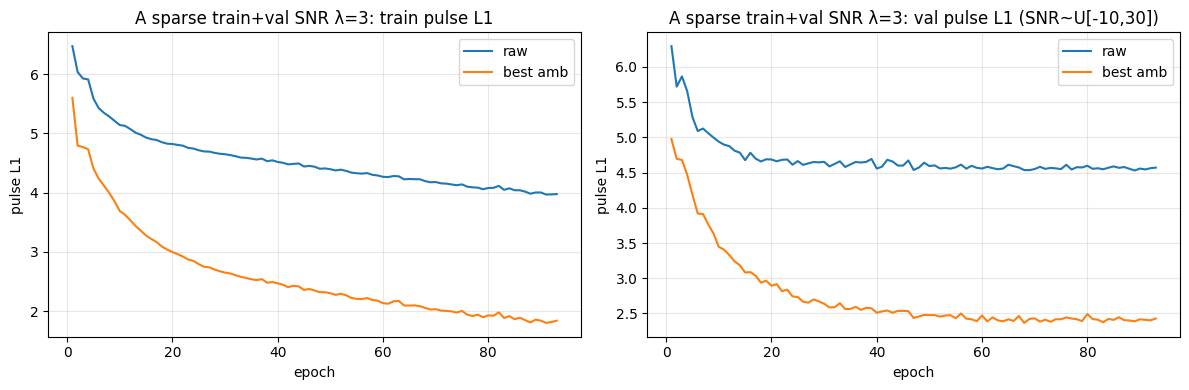

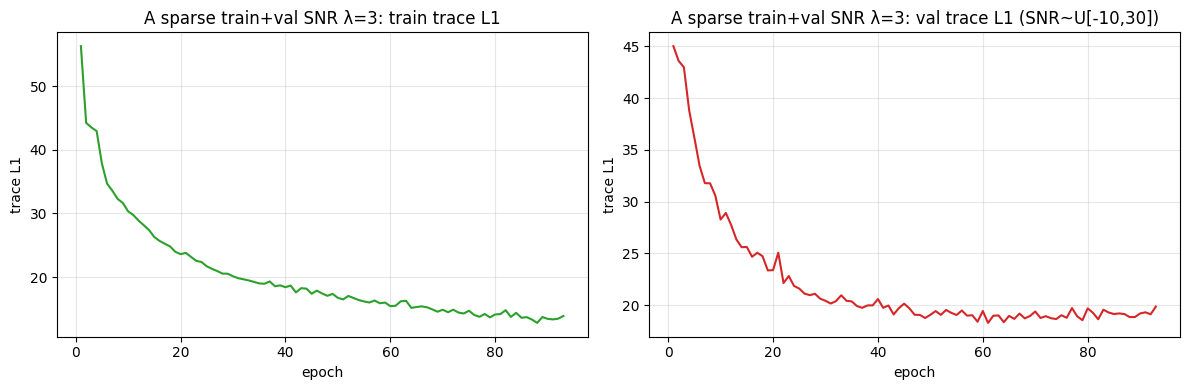

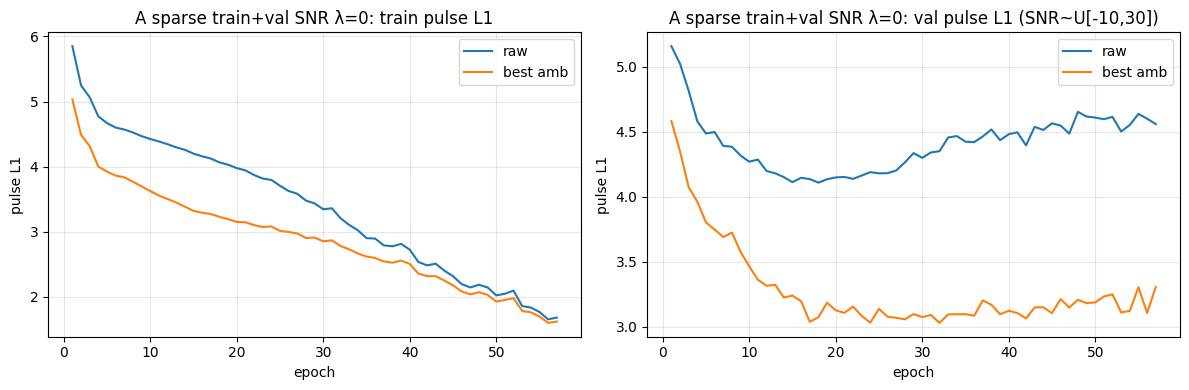

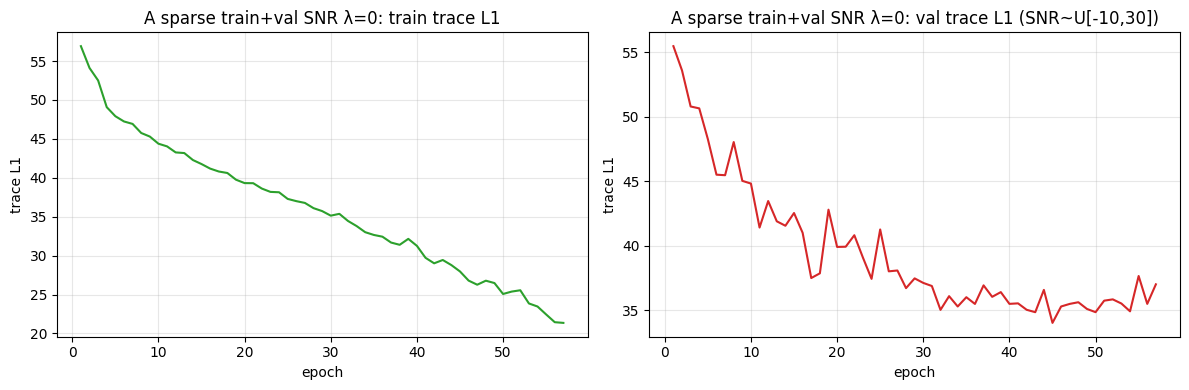

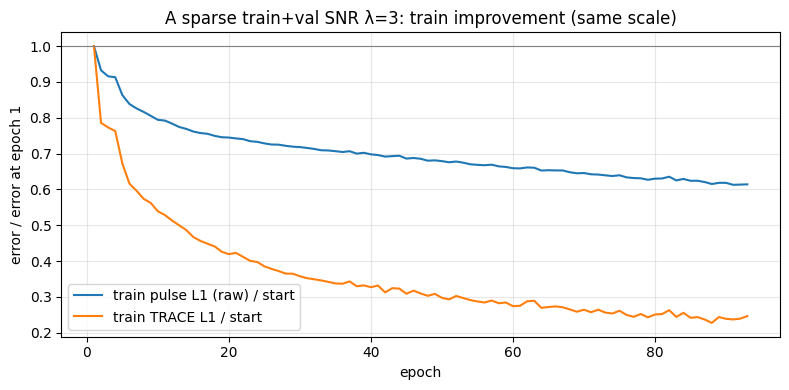

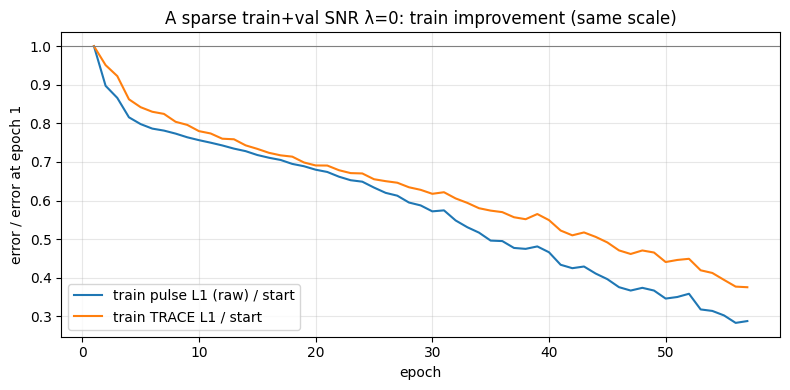

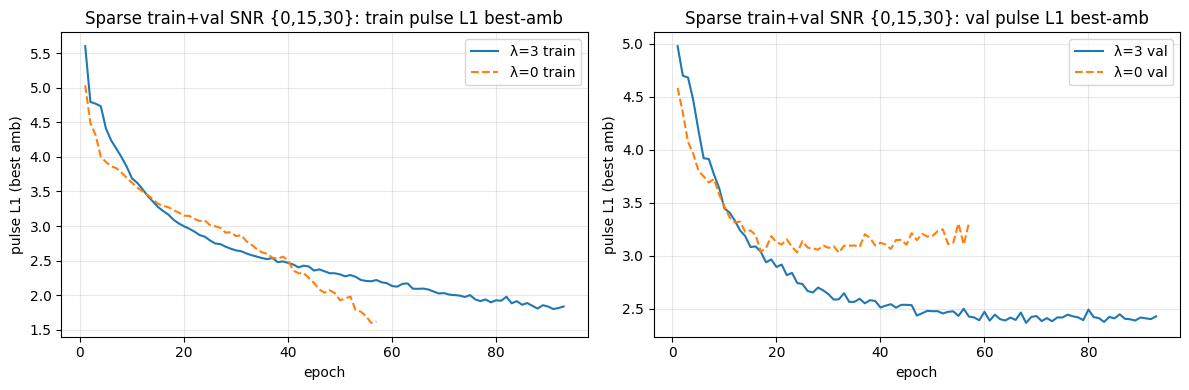

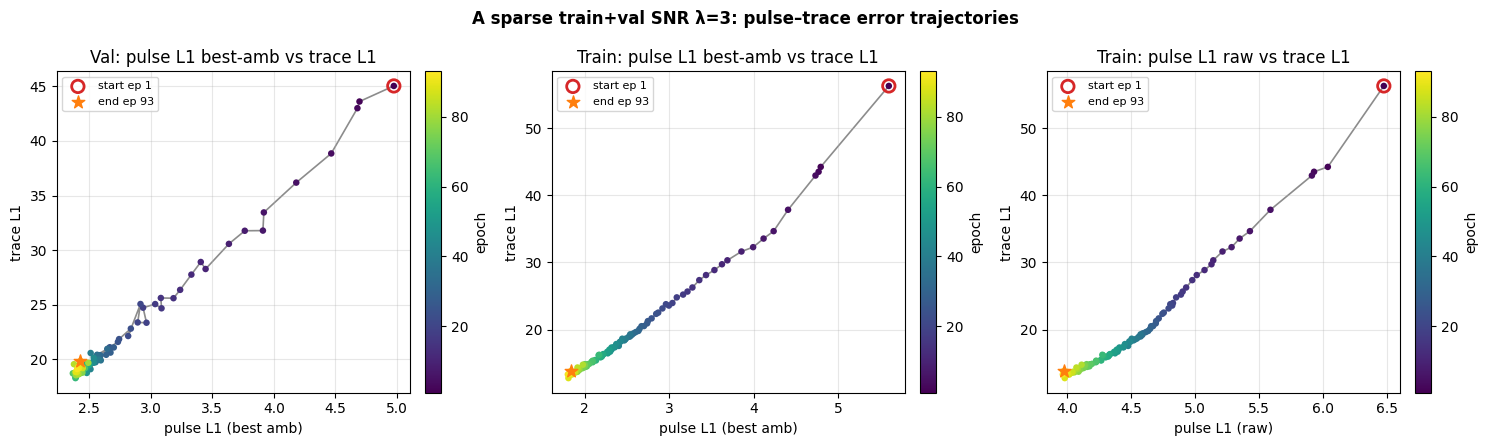

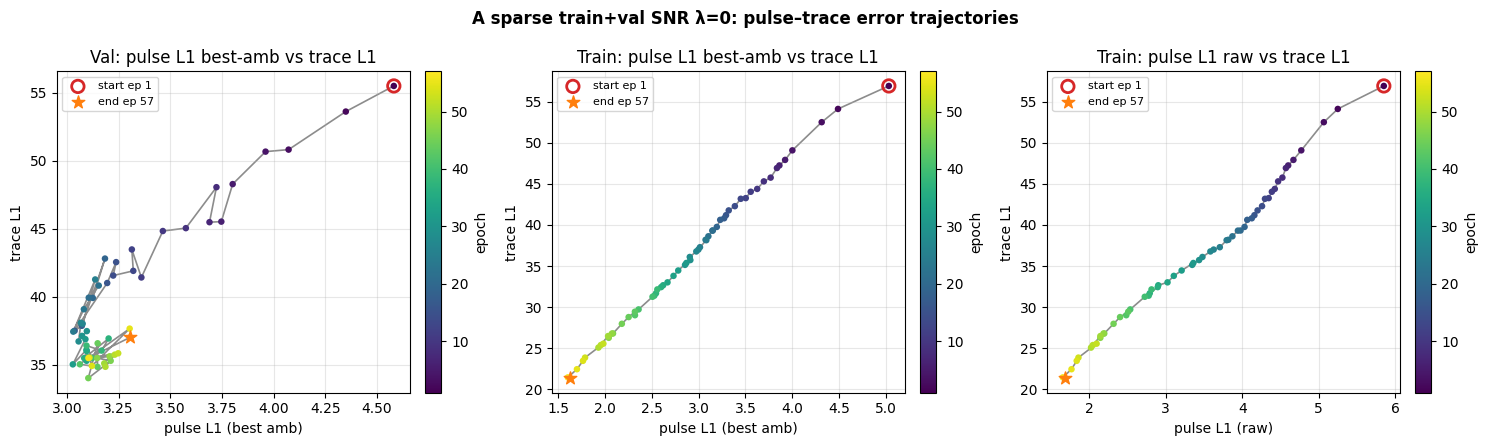

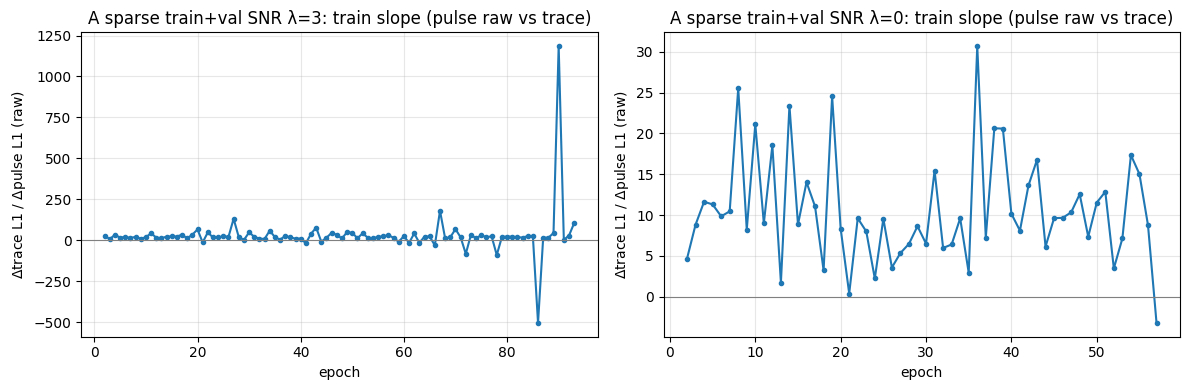

In [58]:
plot_pulse_curves(hist_a_tv3, "A sparse train+val SNR λ=3")
plot_trace_curves(hist_a_tv3, "A sparse train+val SNR λ=3")
plot_pulse_curves(hist_a_tv0, "A sparse train+val SNR λ=0")
# λ=0: trace L1 still logged (diagnostic), not used in the loss
plot_trace_curves(hist_a_tv0, "A sparse train+val SNR λ=0")

# Train improvement trends: pulse raw vs TRACE on a shared relative scale (÷ epoch-1)
for hist, name in [
    (hist_a_tv3, "λ=3"),
    (hist_a_tv0, "λ=0"),
]:
    pulse = np.asarray(hist["train_pulse_l1_raw"], dtype=float)
    trace = np.asarray(hist["train_trace_l1"], dtype=float)
    ep = _epochs(pulse)
    pulse_rel = pulse / max(float(pulse[0]), 1e-8)
    trace_rel = trace / max(float(trace[0]), 1e-8)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, pulse_rel, "-", label="train pulse L1 (raw) / start")
    ax.plot(ep, trace_rel, "-", label="train TRACE L1 / start")
    ax.axhline(1.0, color="0.5", lw=0.8)
    ax.set_xlabel("epoch")
    ax.set_ylabel("error / error at epoch 1")
    ax.set_title(f"A sparse train+val SNR {name}: train improvement (same scale)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name, ls in [
    (hist_a_tv3, "λ=3", "-"),
    (hist_a_tv0, "λ=0", "--"),
]:
    ep = _epochs(hist["val_pulse_l1_amb"])
    axes[0].plot(ep, hist["train_pulse_l1_amb"], ls=ls, label=f"{name} train")
    axes[1].plot(ep, hist["val_pulse_l1_amb"], ls=ls, label=f"{name} val")
axes[0].set_title("Sparse train+val SNR {0,15,30}: train pulse L1 best-amb")
axes[1].set_title("Sparse train+val SNR {0,15,30}: val pulse L1 best-amb")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.set_ylabel("pulse L1 (best amb)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pulse–trace error trajectories (same layout as Model A early in the notebook)
plot_pulse_trace_trajectories(hist_a_tv3, "A sparse train+val SNR λ=3")
plot_pulse_trace_trajectories(hist_a_tv0, "A sparse train+val SNR λ=0")


def _d_trace_over_d_pulse_raw(hist, eps=1e-8):
    """Finite-difference slope along train trajectory: Δ(trace L1) / Δ(pulse L1 raw)."""
    pulse = np.asarray(hist["train_pulse_l1_raw"], dtype=float)
    trace = np.asarray(hist["train_trace_l1"], dtype=float)
    ep = _epochs(pulse)
    d_pulse = np.diff(pulse)
    d_trace = np.diff(trace)
    slope = np.full_like(d_pulse, np.nan, dtype=float)
    ok = np.abs(d_pulse) > eps
    slope[ok] = d_trace[ok] / d_pulse[ok]
    # attribute each step to the later epoch
    return ep[1:], slope


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, hist, name in [
    (axes[0], hist_a_tv3, "λ=3"),
    (axes[1], hist_a_tv0, "λ=0"),
]:
    ep_s, slope = _d_trace_over_d_pulse_raw(hist)
    ax.plot(ep_s, slope, "o-", markersize=3, color="C0")
    ax.axhline(0.0, color="0.5", lw=0.8)
    ax.set_xlabel("epoch")
    ax.set_ylabel(r"$\Delta$trace L1 / $\Delta$pulse L1 (raw)")
    ax.set_title(f"A sparse train+val SNR {name}: train slope (pulse raw vs trace)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Held-out test SNR sweep — sparse train+val A (λ=3 / λ=0) vs Model A old

Compare against the original Model A (`model_a_raw_pulse_loss`: λ=3, train SNR U[0, 30], val U[-10, 30]).


   SNR      A old       tv λ=3       tv λ=0   Δ(3−old)     Δ(0−3)
   -10     3.3990       3.3827       3.4519    -0.0163     0.0692
    -5     2.7537       2.7201       3.2131    -0.0336     0.4930
     0     2.5618       2.5157       3.1178    -0.0461     0.6021
     5     2.4872       2.4793       3.0923    -0.0079     0.6130
    10     2.4499       2.4677       3.0811     0.0178     0.6134
    15     2.4454       2.4666       3.0660     0.0212     0.5993
    20     2.4406       2.4590       3.0645     0.0184     0.6055
    25     2.4402       2.4627       3.0669     0.0225     0.6042
    30     2.4413       2.4646       3.0654     0.0233     0.6009


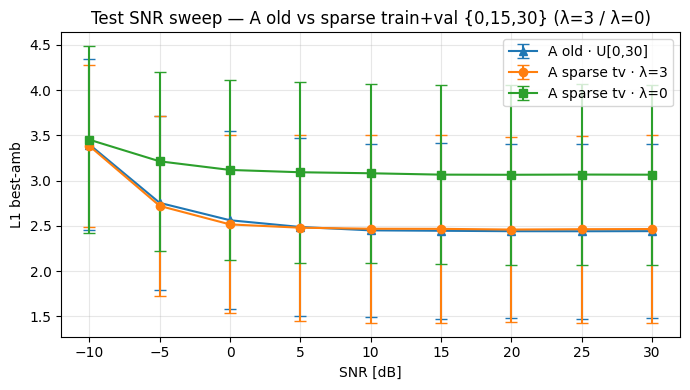

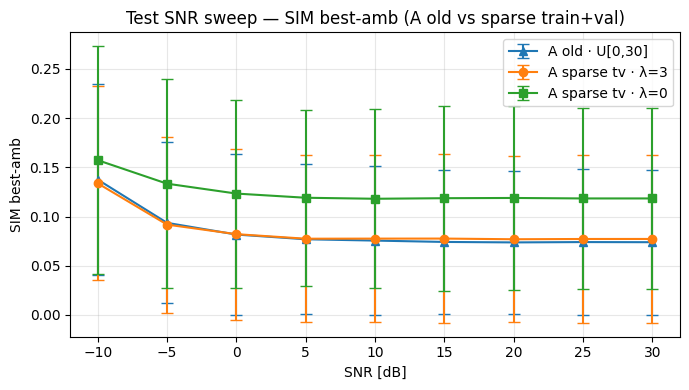

In [54]:
from evaluate_cnn import load_cnn_sweep, plot_metric_curves

if "test_loader" not in globals():
    test_loader = diag.build_data_c_test_loader(
        n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=SEED, device=DEVICE
    )

tag_a_old = globals().get("tag_a", globals().get("tag_a_old", "model_a_raw_pulse_loss"))
sweep_path_a_old = OUT / f"{tag_a_old}_test_snr_sweep.npz"
sweep_path_tv3 = OUT / f"{tag_a_sparse_tv_lam3}_test_snr_sweep.npz"
sweep_path_tv0 = OUT / f"{tag_a_sparse_tv_lam0}_test_snr_sweep.npz"

if not sweep_path_a_old.exists():
    raise FileNotFoundError(
        f"Missing Model A old sweep: {sweep_path_a_old} "
        "(run the early Held-out test SNR sweep cell first)."
    )

for tag, path in [
    (tag_a_sparse_tv_lam3, sweep_path_tv3),
    (tag_a_sparse_tv_lam0, sweep_path_tv0),
]:
    if RUN_TEST_SWEEP_A_SPARSE_TV and (FORCE_TEST_SWEEP_A_SPARSE_TV or not path.exists()):
        print("Running SNR sweep —", tag)
        diag.run_and_save_test_snr_sweep(
            OUT / f"{tag}_model.pt",
            path,
            test_loader=test_loader,
            snr_sweep_db=SNR_SWEEP_DB,
            device=DEVICE,
            experiment_name=f"data_c_{tag}",
            verbose=True,
        )

sweep_a_old = load_cnn_sweep(sweep_path_a_old)
sweep_tv3 = load_cnn_sweep(sweep_path_tv3)
sweep_tv0 = load_cnn_sweep(sweep_path_tv0)

print(
    f"{'SNR':>6} {'A old':>10} {'tv λ=3':>12} {'tv λ=0':>12} "
    f"{'Δ(3−old)':>10} {'Δ(0−3)':>10}"
)
for i, snr in enumerate(sweep_tv3.snr_sweep_db):
    a_old = float(sweep_a_old.cnn_l1_amb_m[i])
    a3 = float(sweep_tv3.cnn_l1_amb_m[i])
    a0 = float(sweep_tv0.cnn_l1_amb_m[i])
    print(
        f"{float(snr):6.0f} {a_old:10.4f} {a3:12.4f} {a0:12.4f} "
        f"{a3 - a_old:10.4f} {a0 - a3:10.4f}"
    )

plot_metric_curves(
    sweep_tv3.snr_sweep_db,
    [
        (sweep_a_old.cnn_l1_amb_m, sweep_a_old.cnn_l1_amb_s, "^-", "A old · U[0,30]"),
        (sweep_tv3.cnn_l1_amb_m, sweep_tv3.cnn_l1_amb_s, "o-", "A sparse tv · λ=3"),
        (sweep_tv0.cnn_l1_amb_m, sweep_tv0.cnn_l1_amb_s, "s-", "A sparse tv · λ=0"),
    ],
    xlabel="SNR [dB]",
    ylabel="L1 best-amb",
    title="Test SNR sweep — A old vs sparse train+val {0,15,30} (λ=3 / λ=0)",
)
plot_metric_curves(
    sweep_tv3.snr_sweep_db,
    [
        (sweep_a_old.cnn_sim_amb_m, sweep_a_old.cnn_sim_amb_s, "^-", "A old · U[0,30]"),
        (sweep_tv3.cnn_sim_amb_m, sweep_tv3.cnn_sim_amb_s, "o-", "A sparse tv · λ=3"),
        (sweep_tv0.cnn_sim_amb_m, sweep_tv0.cnn_sim_amb_s, "s-", "A sparse tv · λ=0"),
    ],
    xlabel="SNR [dB]",
    ylabel="SIM best-amb",
    title="Test SNR sweep — SIM best-amb (A old vs sparse train+val)",
)
